In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")

# Load data (same as your notebook)
df = pd.read_csv("Superstore_Cleaned.csv")
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Ship_Date'] = pd.to_datetime(df['Ship_Date'])
df['Month_Name'] = df['Order_Date'].dt.strftime('%b')


In [2]:
df

,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,City,State,Postal_Code,...,Product_Name,Sales,Quantity,Discount,Profit,Days_to_Ship,Order_Year,Order_Month,Order_Quarter,Month_Name
0,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,Henderson,Kentucky,42420,...,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,3,2016,11,4,Nov
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,Henderson,Kentucky,42420,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,3,2016,11,4,Nov
2,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,Los Angeles,California,90036,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,4,2016,6,2,Jun
3,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,Fort Lauderdale,Florida,33311,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,7,2015,10,4,Oct
4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,Fort Lauderdale,Florida,33311,...,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,7,2015,10,4,Oct
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9981,CA-2014-110422,2014-01-21,2014-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,Miami,Florida,33180,...,Ultra Door Pull Handle,25.2480,3,0.20,4.1028,2,2014,1,1,Jan
9982,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,Costa Mesa,California,92627,...,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332,5,2017,2,1,Feb
9983,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,Costa Mesa,California,92627,...,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932,5,2017,2,1,Feb
9984,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,Costa Mesa,California,92627,...,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200,5,2017,2,1,Feb


In [3]:
# --- Cell 1: Dashboard Header ---
# (Markdown cell - paste as Markdown in notebook)
# ## 📊 Dashboard 1: Customer-Centric Analysis
# > Understanding customer segments, profitability, loyalty, and regional performance.


DASHBOARD 1: CUSTOMER-CENTRIC ANALYSIS


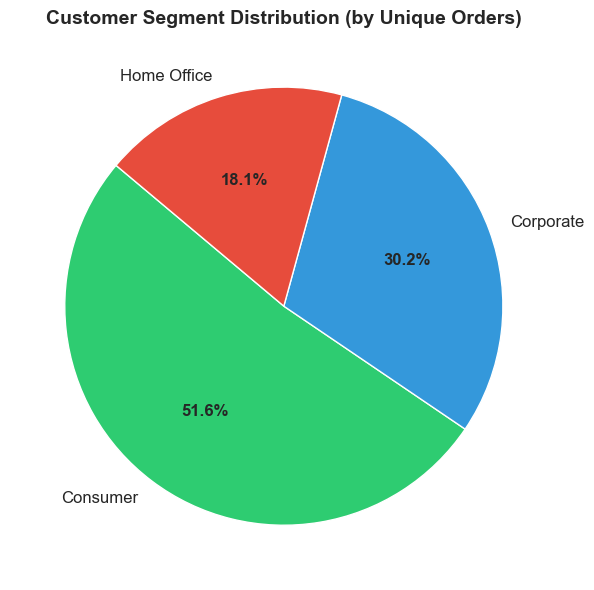

In [4]:
# --- Cell 2: Customer Segment Distribution (Pie Chart) ---
print("=" * 60)
print("DASHBOARD 1: CUSTOMER-CENTRIC ANALYSIS")
print("=" * 60)

segment_counts = df.groupby('Segment')['Order_ID'].nunique()

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#2ecc71', '#3498db', '#e74c3c']
wedges, texts, autotexts = ax.pie(
    segment_counts.values,
    labels=segment_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    textprops={'fontsize': 12}
)
for autotext in autotexts:
    autotext.set_fontweight('bold')
ax.set_title("Customer Segment Distribution (by Unique Orders)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

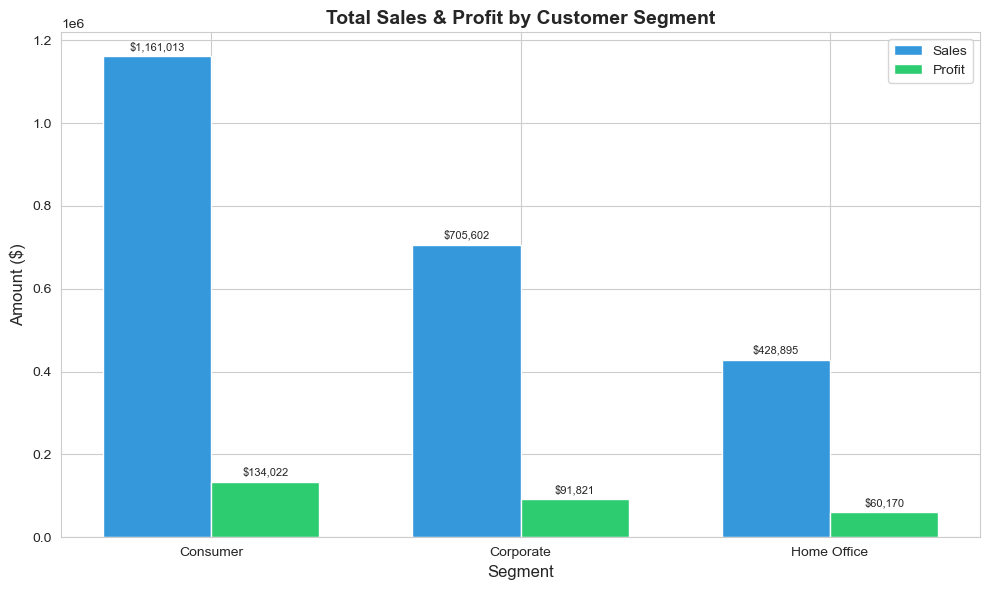

In [5]:
# --- Cell 3: Sales & Profit by Segment (Grouped Bar Chart) ---
segment_data = df.groupby('Segment').agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(segment_data))
width = 0.35

bars1 = ax.bar(x - width/2, segment_data['Sales'], width, label='Sales', color='#3498db')
bars2 = ax.bar(x + width/2, segment_data['Profit'], width, label='Profit', color='#2ecc71')

ax.set_xlabel('Segment', fontsize=12)
ax.set_ylabel('Amount ($)', fontsize=12)
ax.set_title('Total Sales & Profit by Customer Segment', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(segment_data['Segment'])
ax.legend()
ax.bar_label(bars1, fmt='${:,.0f}', padding=3, fontsize=8)
ax.bar_label(bars2, fmt='${:,.0f}', padding=3, fontsize=8)
plt.tight_layout()
plt.show()

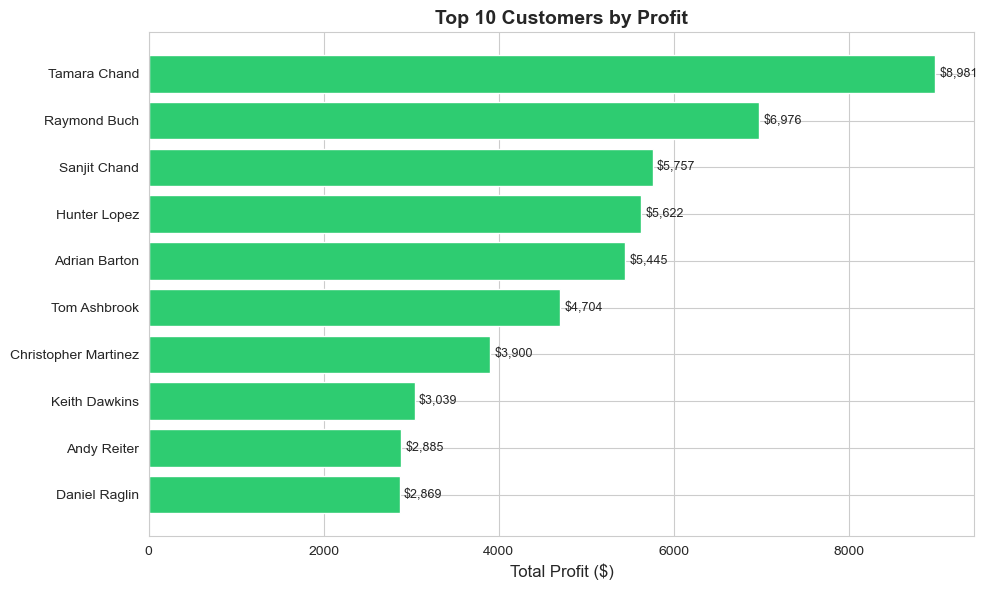

In [6]:
# --- Cell 4: Top 10 Customers by Profit ---
top10_profit_customers = df.groupby('Customer_Name')['Profit'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in top10_profit_customers.values]
bars = ax.barh(top10_profit_customers.index[::-1], top10_profit_customers.values[::-1], color=colors[::-1])
ax.set_xlabel('Total Profit ($)', fontsize=12)
ax.set_title('Top 10 Customers by Profit', fontsize=14, fontweight='bold')
ax.bar_label(bars, fmt='${:,.0f}', padding=3, fontsize=9)
plt.tight_layout()
plt.show()


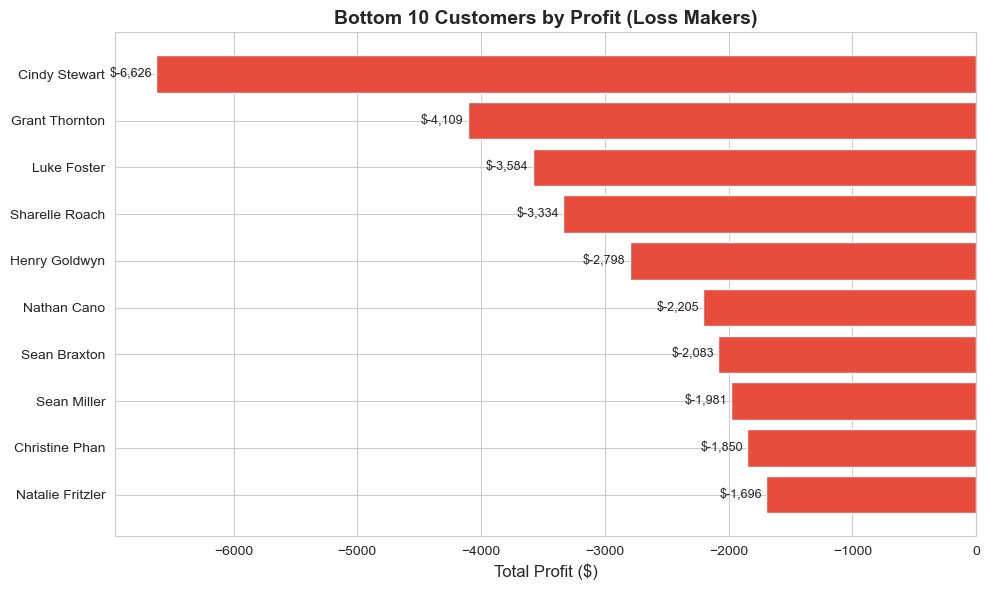

In [7]:
# --- Cell 5: Bottom 10 Customers by Profit (Loss-Making) ---
bottom10_profit_customers = df.groupby('Customer_Name')['Profit'].sum().sort_values(ascending=True).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in bottom10_profit_customers.values]
bars = ax.barh(bottom10_profit_customers.index[::-1], bottom10_profit_customers.values[::-1], color=colors[::-1])
ax.set_xlabel('Total Profit ($)', fontsize=12)
ax.set_title('Bottom 10 Customers by Profit (Loss Makers)', fontsize=14, fontweight='bold')
ax.bar_label(bars, fmt='${:,.0f}', padding=3, fontsize=9)
plt.tight_layout()
plt.show()

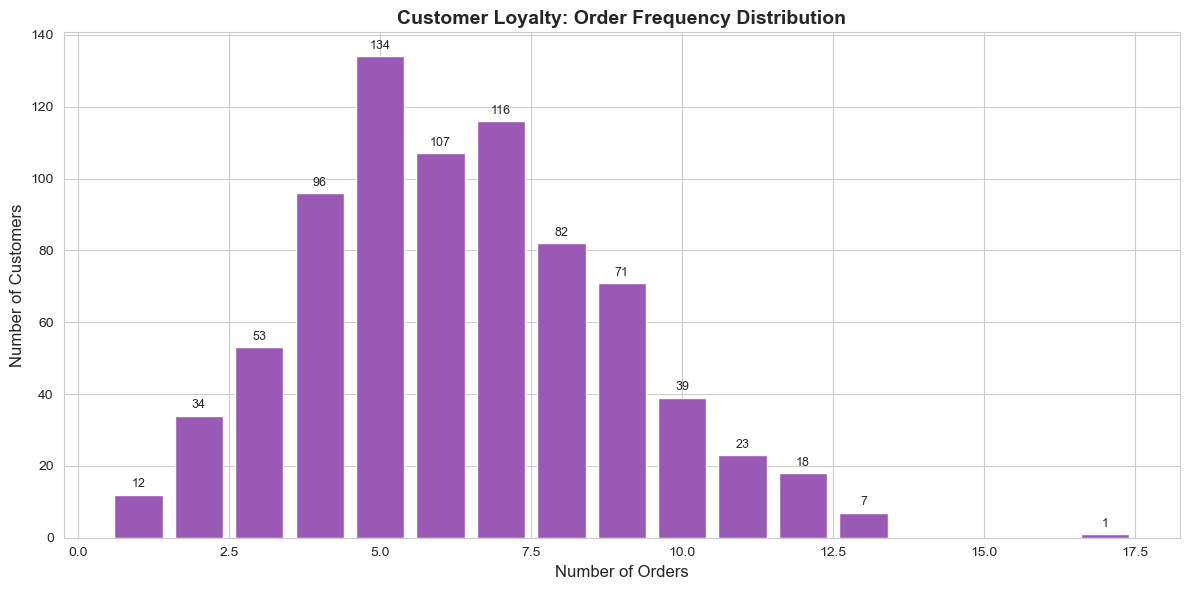


Total Unique Customers: 793
Repeat Customers (>1 order): 781 (98.5%)
Average Orders per Customer: 6.3


In [8]:
# --- Cell 6: Customer Loyalty - Order Frequency Distribution ---
order_frequency = df.groupby('Customer_Name')['Order_ID'].nunique().reset_index()
order_frequency.columns = ['Customer_Name', 'Order_Count']
freq_distribution = order_frequency['Order_Count'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(freq_distribution.index, freq_distribution.values, color='#9b59b6', edgecolor='white')
ax.set_xlabel('Number of Orders', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)
ax.set_title('Customer Loyalty: Order Frequency Distribution', fontsize=14, fontweight='bold')
ax.bar_label(bars, padding=3, fontsize=9)
plt.tight_layout()
plt.show()

# Print loyalty stats
total_customers = order_frequency['Customer_Name'].nunique()
repeat_customers = order_frequency[order_frequency['Order_Count'] > 1].shape[0]
print(f"\nTotal Unique Customers: {total_customers}")
print(f"Repeat Customers (>1 order): {repeat_customers} ({repeat_customers/total_customers*100:.1f}%)")
print(f"Average Orders per Customer: {order_frequency['Order_Count'].mean():.1f}")

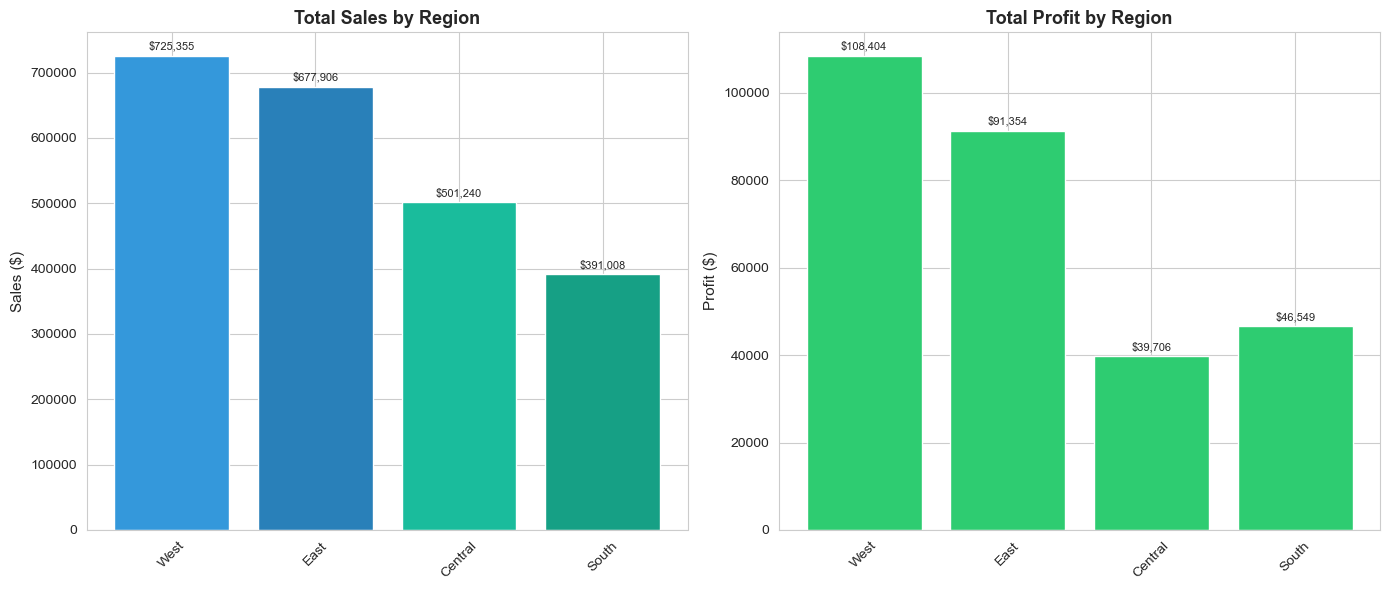

In [9]:
# --- Cell 7: Sales & Profit by Region ---
region_data = df.groupby('Region').agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).reset_index().sort_values('Sales', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Sales by Region
colors_sales = ['#3498db', '#2980b9', '#1abc9c', '#16a085']
bars1 = axes[0].bar(region_data['Region'], region_data['Sales'], color=colors_sales)
axes[0].set_title('Total Sales by Region', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Sales ($)', fontsize=11)
axes[0].bar_label(bars1, fmt='${:,.0f}', padding=3, fontsize=8)
axes[0].tick_params(axis='x', rotation=45)

# Profit by Region
colors_profit = ['#2ecc71' if v > 0 else '#e74c3c' for v in region_data['Profit']]
bars2 = axes[1].bar(region_data['Region'], region_data['Profit'], color=colors_profit)
axes[1].set_title('Total Profit by Region', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Profit ($)', fontsize=11)
axes[1].bar_label(bars2, fmt='${:,.0f}', padding=3, fontsize=8)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

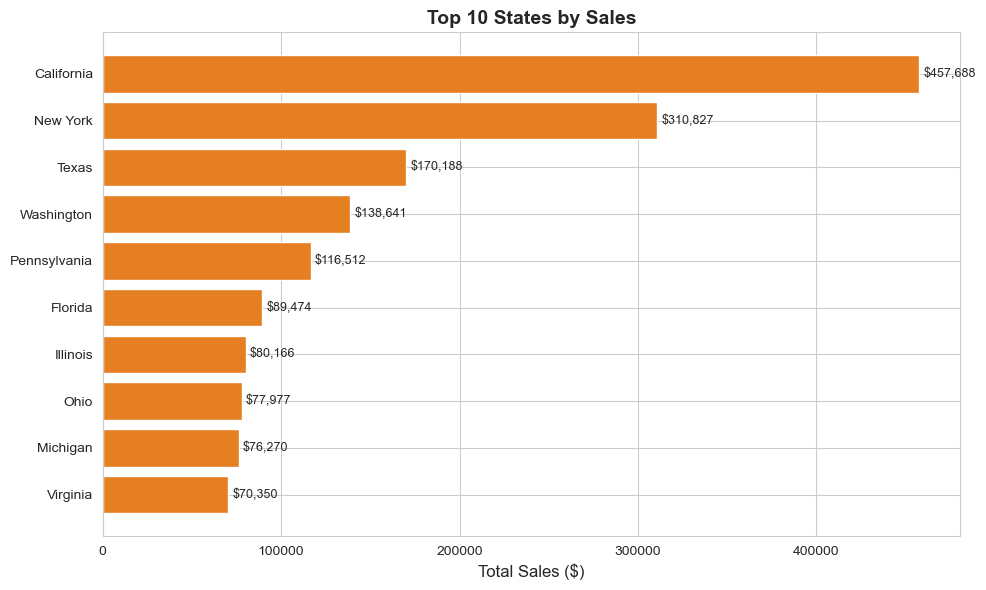

In [10]:

# --- Cell 8: Top 10 States by Sales ---
top10_states = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top10_states.index[::-1], top10_states.values[::-1], color='#e67e22')
ax.set_xlabel('Total Sales ($)', fontsize=12)
ax.set_title('Top 10 States by Sales', fontsize=14, fontweight='bold')
ax.bar_label(bars, fmt='${:,.0f}', padding=3, fontsize=9)
plt.tight_layout()
plt.show()

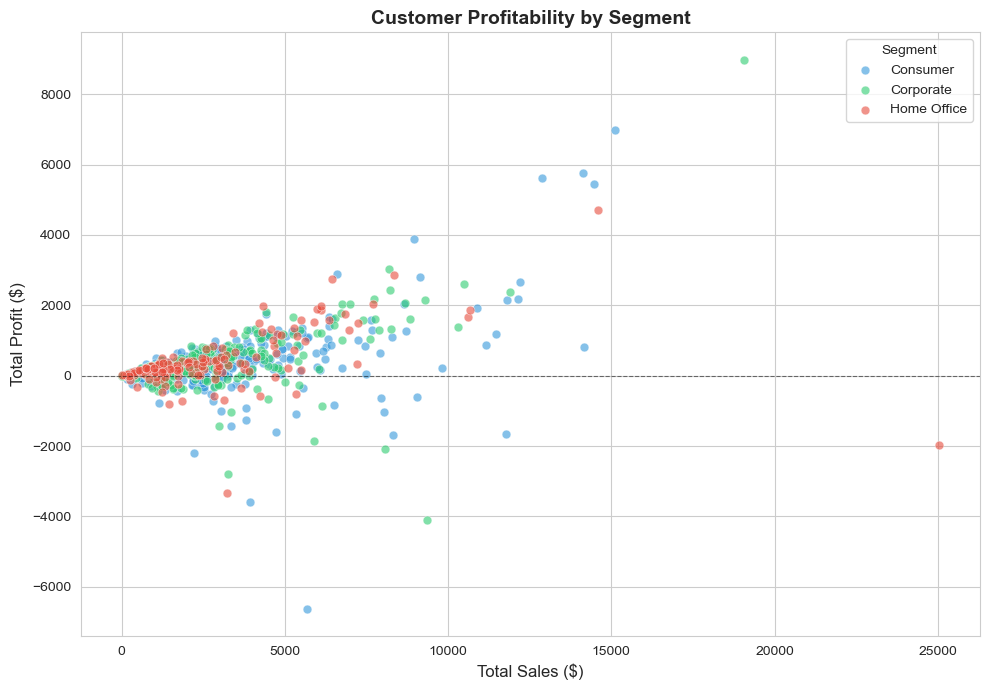

In [11]:
# --- Cell 9: Enhanced Customer Profitability Scatter (color-coded by Segment) ---
customer_data = df.groupby(['Customer_Name', 'Segment']).agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum'
}).reset_index()

fig, ax = plt.subplots(figsize=(10, 7))
segment_colors = {'Consumer': '#3498db', 'Corporate': '#2ecc71', 'Home Office': '#e74c3c'}
for segment, color in segment_colors.items():
    mask = customer_data['Segment'] == segment
    ax.scatter(
        customer_data.loc[mask, 'Sales'],
        customer_data.loc[mask, 'Profit'],
        c=color, label=segment, alpha=0.6, s=40, edgecolors='white', linewidth=0.5
    )

ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_xlabel('Total Sales ($)', fontsize=12)
ax.set_ylabel('Total Profit ($)', fontsize=12)
ax.set_title('Customer Profitability by Segment', fontsize=14, fontweight='bold')
ax.legend(title='Segment', fontsize=10)
plt.tight_layout()
plt.show()

In [12]:
# --- Cell 10: Customer Dashboard Summary ---
print("\n" + "=" * 60)
print("CUSTOMER-CENTRIC DASHBOARD — KEY INSIGHTS")
print("=" * 60)

# Top segment
top_segment = segment_data.loc[segment_data['Sales'].idxmax()]
print(f"\n1. Top Segment by Sales: {top_segment['Segment']} (${top_segment['Sales']:,.0f})")

# Top region
top_region = region_data.iloc[0]
print(f"2. Top Region by Sales: {top_region['Region']} (${top_region['Sales']:,.0f})")

# Top customer
top_cust = top10_profit_customers.index[0]
print(f"3. Most Profitable Customer: {top_cust} (${top10_profit_customers.iloc[0]:,.0f})")

# Loss-making customers count
loss_customers = df.groupby('Customer_Name')['Profit'].sum()
loss_count = (loss_customers < 0).sum()
print(f"4. Number of Loss-Making Customers: {loss_count} out of {total_customers} ({loss_count/total_customers*100:.1f}%)")

print(f"5. Repeat Customer Rate: {repeat_customers/total_customers*100:.1f}%")
print(f"6. Avg Orders per Customer: {order_frequency['Order_Count'].mean():.1f}")


CUSTOMER-CENTRIC DASHBOARD — KEY INSIGHTS

1. Top Segment by Sales: Consumer ($1,161,013)
2. Top Region by Sales: West ($725,355)
3. Most Profitable Customer: Tamara Chand ($8,981)
4. Number of Loss-Making Customers: 155 out of 793 (19.5%)
5. Repeat Customer Rate: 98.5%
6. Avg Orders per Customer: 6.3


In [13]:
# ============================================================================
# DASHBOARD 2: PRODUCT-CENTRIC
# ============================================================================

# --- Cell 11: Dashboard Header ---
# (Markdown cell - paste as Markdown in notebook)
# ## 📦 Dashboard 2: Product-Centric Analysis
# > Analyzing category performance, sub-category profitability, and discount impact.

print("\n\n" + "=" * 60)
print("DASHBOARD 2: PRODUCT-CENTRIC ANALYSIS")
print("=" * 60)



DASHBOARD 2: PRODUCT-CENTRIC ANALYSIS


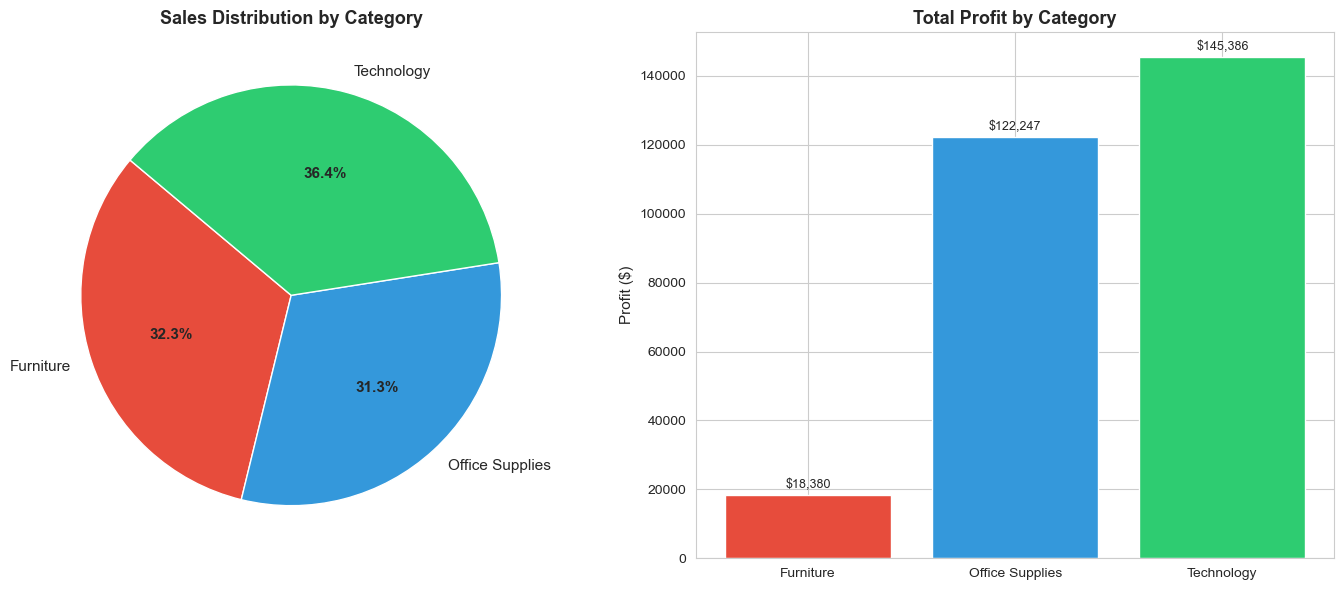

In [14]:
# --- Cell 12: Sales by Category (Pie + Bar) ---
category_data = df.groupby('Category').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum'
}).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart
colors_cat = ['#e74c3c', '#3498db', '#2ecc71']
wedges, texts, autotexts = axes[0].pie(
    category_data['Sales'], labels=category_data['Category'],
    autopct='%1.1f%%', colors=colors_cat, startangle=140,
    textprops={'fontsize': 11}
)
for autotext in autotexts:
    autotext.set_fontweight('bold')
axes[0].set_title('Sales Distribution by Category', fontsize=13, fontweight='bold')

# Bar chart
bars = axes[1].bar(category_data['Category'], category_data['Profit'], color=colors_cat)
axes[1].set_title('Total Profit by Category', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Profit ($)', fontsize=11)
axes[1].bar_label(bars, fmt='${:,.0f}', padding=3, fontsize=9)

plt.tight_layout()
plt.show()

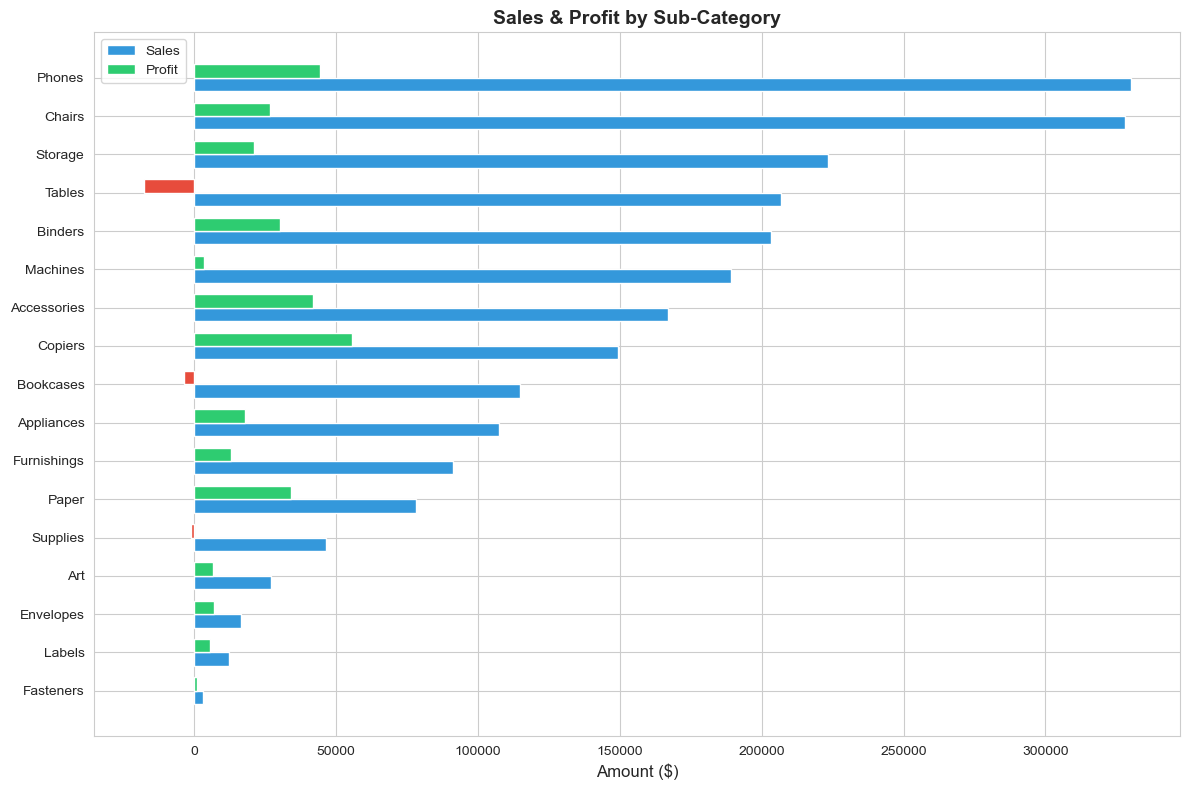

In [15]:
# --- Cell 13: Sales & Profit by Sub-Category (Grouped Horizontal Bar) ---
subcat_data = df.groupby('Sub-Category').agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).reset_index().sort_values('Sales', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
y = np.arange(len(subcat_data))
height = 0.35

bars1 = ax.barh(y - height/2, subcat_data['Sales'], height, label='Sales', color='#3498db')
bars2 = ax.barh(y + height/2, subcat_data['Profit'], height, label='Profit',
                color=['#2ecc71' if v > 0 else '#e74c3c' for v in subcat_data['Profit']])

ax.set_yticks(y)
ax.set_yticklabels(subcat_data['Sub-Category'])
ax.set_xlabel('Amount ($)', fontsize=12)
ax.set_title('Sales & Profit by Sub-Category', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


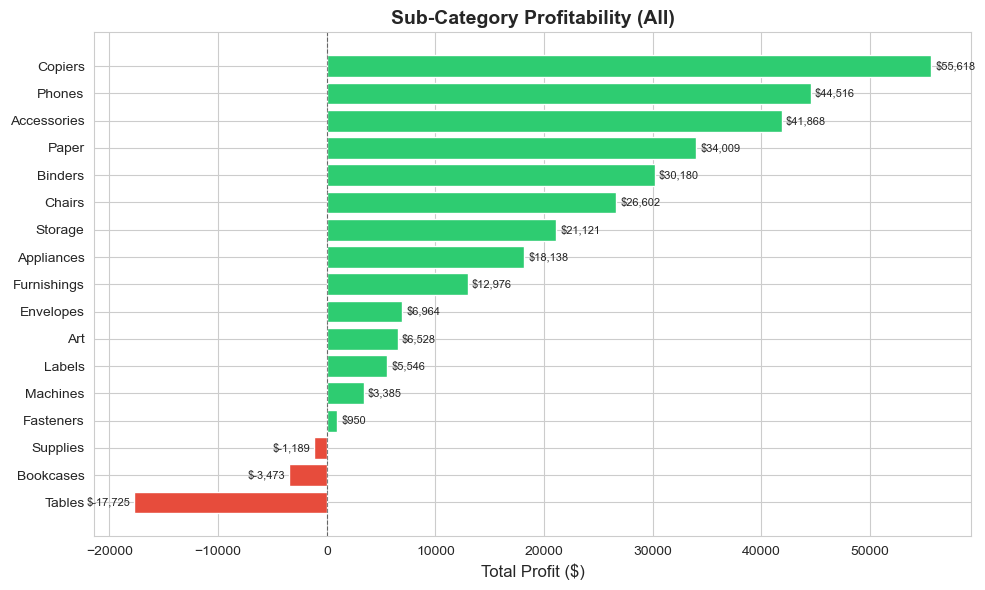

In [16]:
# --- Cell 14: Top 10 Sub-Categories by Profit ---
subcat_profit_sorted = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in subcat_profit_sorted.values]
bars = ax.barh(subcat_profit_sorted.index[::-1], subcat_profit_sorted.values[::-1], color=colors[::-1])
ax.set_xlabel('Total Profit ($)', fontsize=12)
ax.set_title('Sub-Category Profitability (All)', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.bar_label(bars, fmt='${:,.0f}', padding=3, fontsize=8)
plt.tight_layout()
plt.show()

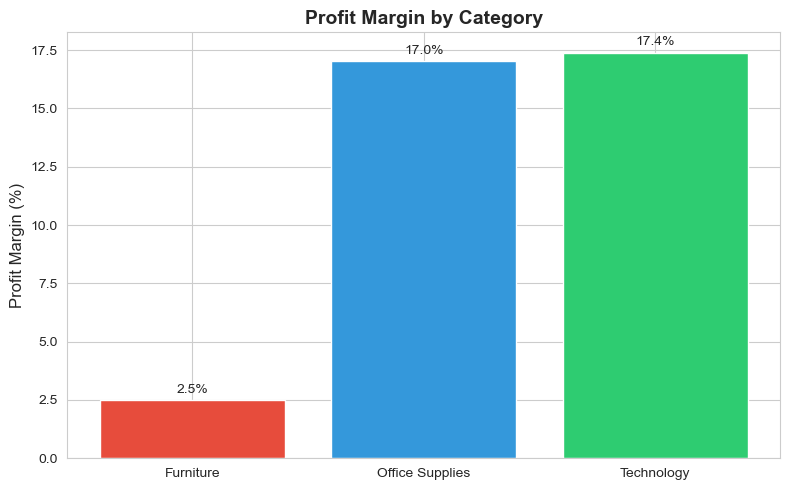

In [17]:
# --- Cell 15: Profit Margin by Category ---
category_data['Profit_Margin'] = (category_data['Profit'] / category_data['Sales']) * 100

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#e74c3c', '#3498db', '#2ecc71']
bars = ax.bar(category_data['Category'], category_data['Profit_Margin'], color=colors)
ax.set_ylabel('Profit Margin (%)', fontsize=12)
ax.set_title('Profit Margin by Category', fontsize=14, fontweight='bold')
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=10)
plt.tight_layout()
plt.show()

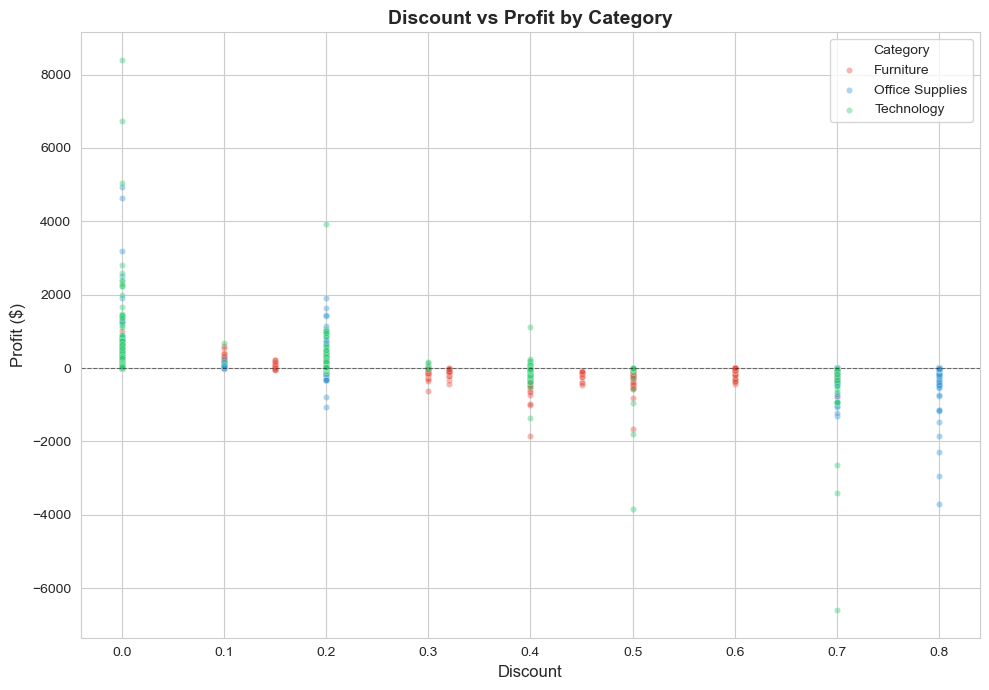

In [18]:
# --- Cell 16: Discount vs Profit by Category (Scatter) ---
fig, ax = plt.subplots(figsize=(10, 7))
cat_colors = {'Furniture': '#e74c3c', 'Office Supplies': '#3498db', 'Technology': '#2ecc71'}
for cat, color in cat_colors.items():
    mask = df['Category'] == cat
    ax.scatter(
        df.loc[mask, 'Discount'],
        df.loc[mask, 'Profit'],
        c=color, label=cat, alpha=0.4, s=20, edgecolors='white', linewidth=0.3
    )

ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_xlabel('Discount', fontsize=12)
ax.set_ylabel('Profit ($)', fontsize=12)
ax.set_title('Discount vs Profit by Category', fontsize=14, fontweight='bold')
ax.legend(title='Category', fontsize=10)
plt.tight_layout()
plt.show()

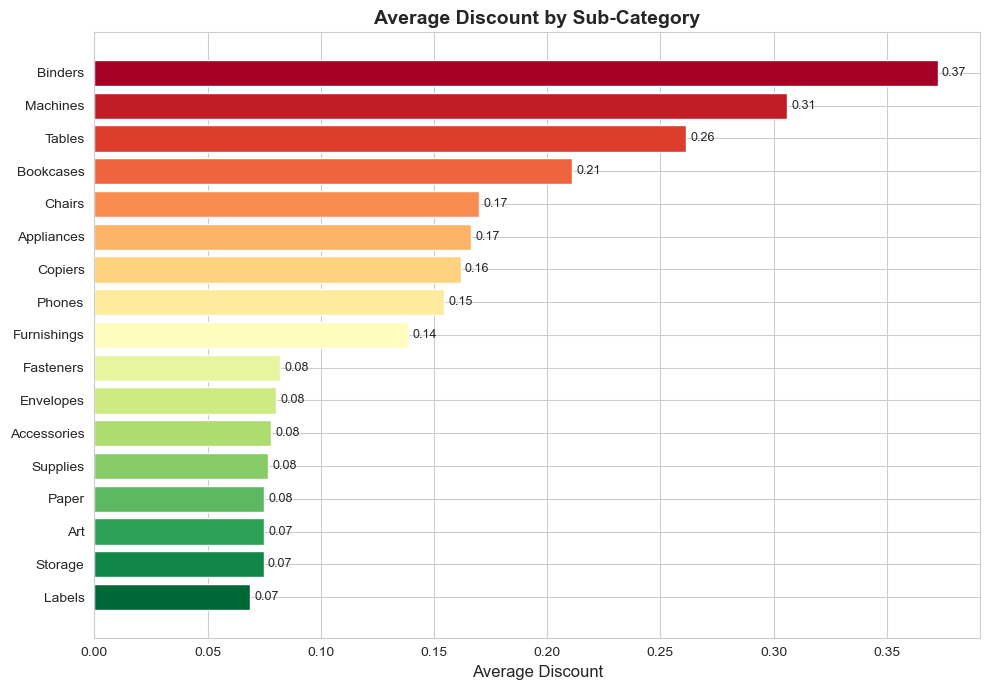

In [19]:
# --- Cell 17: Average Discount by Sub-Category ---
avg_discount = df.groupby('Sub-Category')['Discount'].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.RdYlGn_r(np.linspace(0, 1, len(avg_discount)))
bars = ax.barh(avg_discount.index, avg_discount.values, color=colors)
ax.set_xlabel('Average Discount', fontsize=12)
ax.set_title('Average Discount by Sub-Category', fontsize=14, fontweight='bold')
ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)
plt.tight_layout()
plt.show()

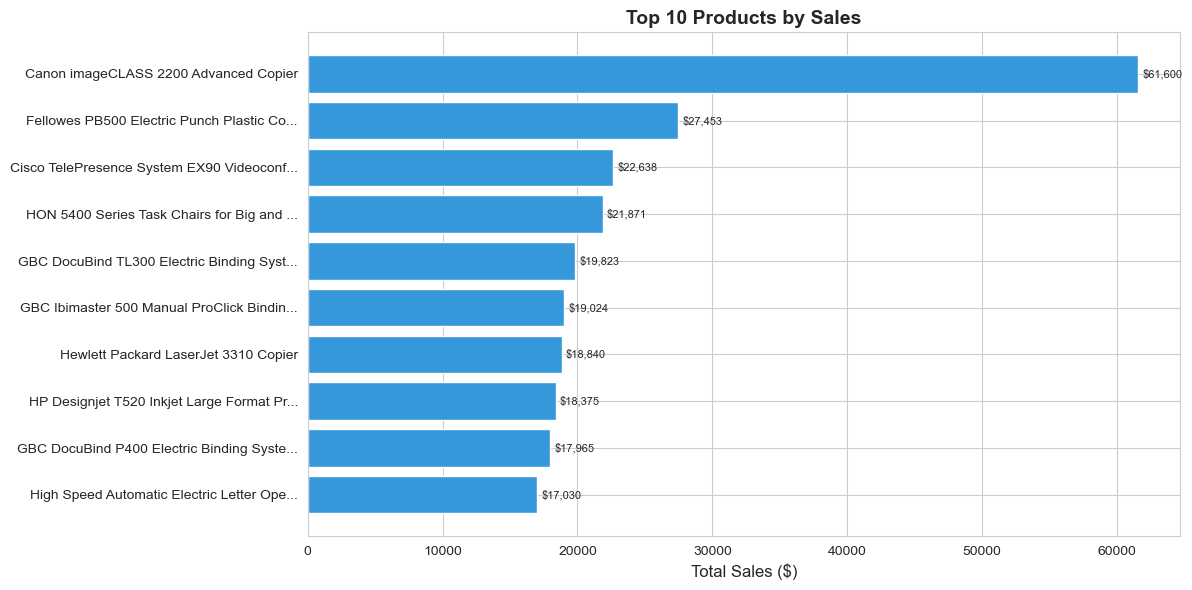

In [20]:
# --- Cell 18: Top 10 Products by Sales ---
top10_products_sales = df.groupby('Product_Name')['Sales'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(
    [name[:40] + '...' if len(name) > 40 else name for name in top10_products_sales.index[::-1]],
    top10_products_sales.values[::-1],
    color='#3498db'
)
ax.set_xlabel('Total Sales ($)', fontsize=12)
ax.set_title('Top 10 Products by Sales', fontsize=14, fontweight='bold')
ax.bar_label(bars, fmt='${:,.0f}', padding=3, fontsize=8)
plt.tight_layout()
plt.show()

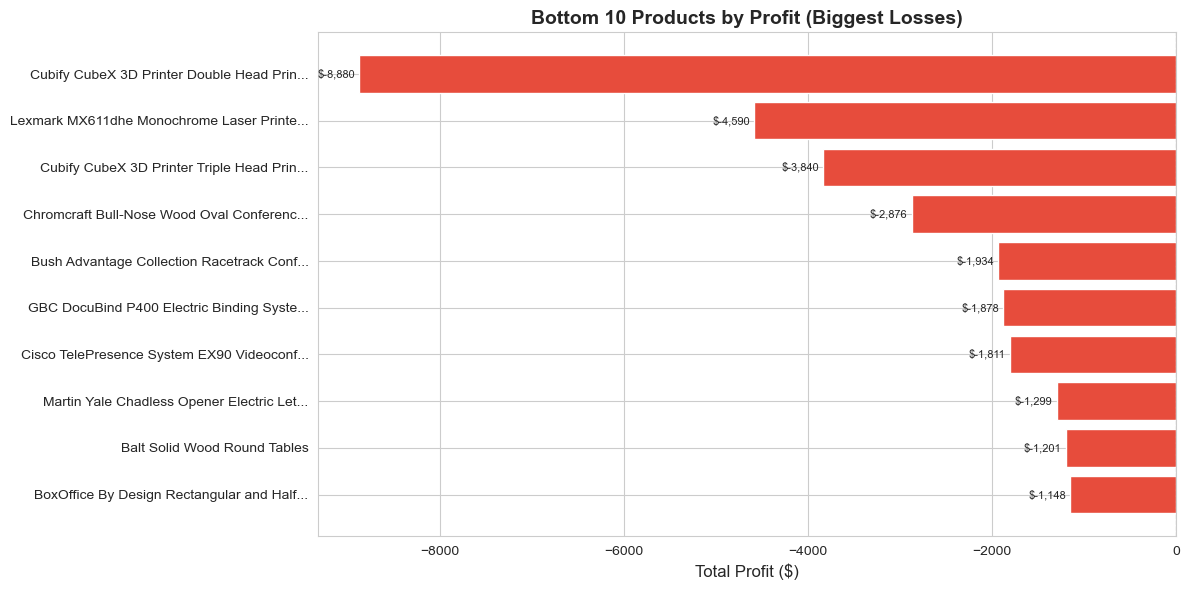

In [21]:

# --- Cell 19: Bottom 10 Products by Profit ---
bottom10_products_profit = df.groupby('Product_Name')['Profit'].sum().sort_values(ascending=True).head(10)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(
    [name[:40] + '...' if len(name) > 40 else name for name in bottom10_products_profit.index[::-1]],
    bottom10_products_profit.values[::-1],
    color='#e74c3c'
)
ax.set_xlabel('Total Profit ($)', fontsize=12)
ax.set_title('Bottom 10 Products by Profit (Biggest Losses)', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.bar_label(bars, fmt='${:,.0f}', padding=3, fontsize=8)
plt.tight_layout()
plt.show()

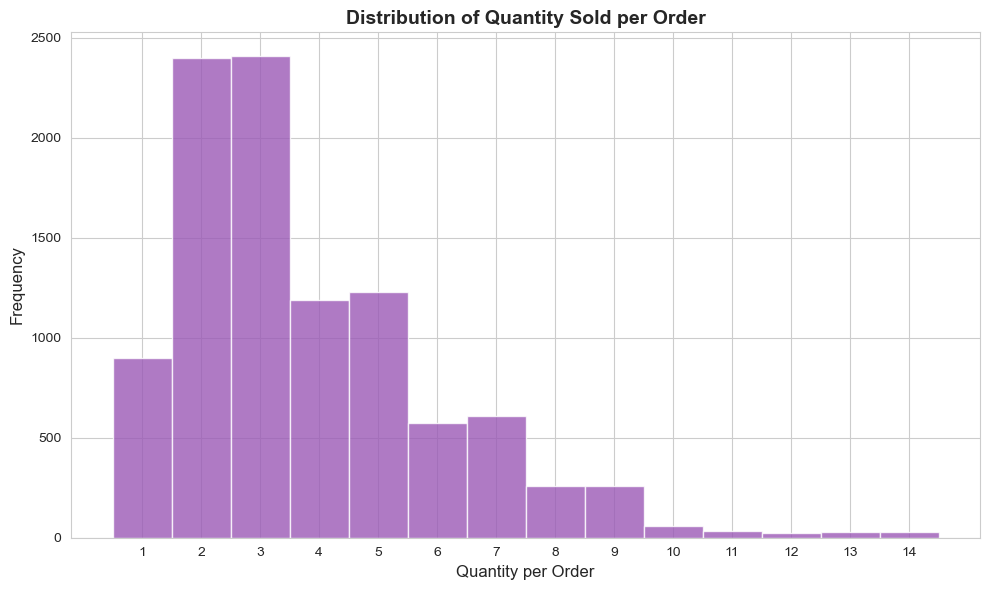

In [22]:
# --- Cell 20: Quantity Sold Distribution ---
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df['Quantity'], bins=range(1, df['Quantity'].max() + 2), color='#9b59b6',
        edgecolor='white', alpha=0.8, align='left')
ax.set_xlabel('Quantity per Order', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Quantity Sold per Order', fontsize=14, fontweight='bold')
ax.set_xticks(range(1, df['Quantity'].max() + 1))
plt.tight_layout()
plt.show()

In [23]:
# --- Cell 21: Product Dashboard Summary ---
print("\n" + "=" * 60)
print("PRODUCT-CENTRIC DASHBOARD — KEY INSIGHTS")
print("=" * 60)

top_cat = category_data.loc[category_data['Profit'].idxmax()]
print(f"\n1. Most Profitable Category: {top_cat['Category']} (${top_cat['Profit']:,.0f})")

worst_subcat = subcat_profit_sorted[subcat_profit_sorted < 0]
if len(worst_subcat) > 0:
    print(f"2. Loss-Making Sub-Categories: {', '.join(worst_subcat.index)}")
else:
    print(f"2. No loss-making sub-categories found")

best_margin_cat = category_data.loc[category_data['Profit_Margin'].idxmax()]
print(f"3. Highest Margin Category: {best_margin_cat['Category']} ({best_margin_cat['Profit_Margin']:.1f}%)")

high_discount = df[df['Discount'] > 0.3]
high_discount_profit = high_discount['Profit'].sum()
print(f"4. Profit from Orders with >30% Discount: ${high_discount_profit:,.0f}")

avg_qty = df['Quantity'].mean()
print(f"5. Average Quantity per Order: {avg_qty:.1f}")

total_products = df['Product_Name'].nunique()
loss_products = df.groupby('Product_Name')['Profit'].sum()
loss_product_count = (loss_products < 0).sum()
print(f"6. Loss-Making Products: {loss_product_count} out of {total_products} ({loss_product_count/total_products*100:.1f}%)")



PRODUCT-CENTRIC DASHBOARD — KEY INSIGHTS

1. Most Profitable Category: Technology ($145,386)
2. Loss-Making Sub-Categories: Supplies, Bookcases, Tables
3. Highest Margin Category: Technology (17.4%)
4. Profit from Orders with >30% Discount: $-125,007
5. Average Quantity per Order: 3.8
6. Loss-Making Products: 301 out of 1850 (16.3%)


In [24]:
# ============================================================================
# DASHBOARD 3: TIME SERIES-CENTRIC
# ============================================================================

# --- Cell 22: Dashboard Header ---
# (Markdown cell - paste as Markdown in notebook)
# ## 📈 Dashboard 3: Time Series Analysis
# > Tracking sales trends, seasonality, growth, and shipping performance over time.

print("\n\n" + "=" * 60)
print("DASHBOARD 3: TIME SERIES-CENTRIC ANALYSIS")
print("=" * 60)



DASHBOARD 3: TIME SERIES-CENTRIC ANALYSIS


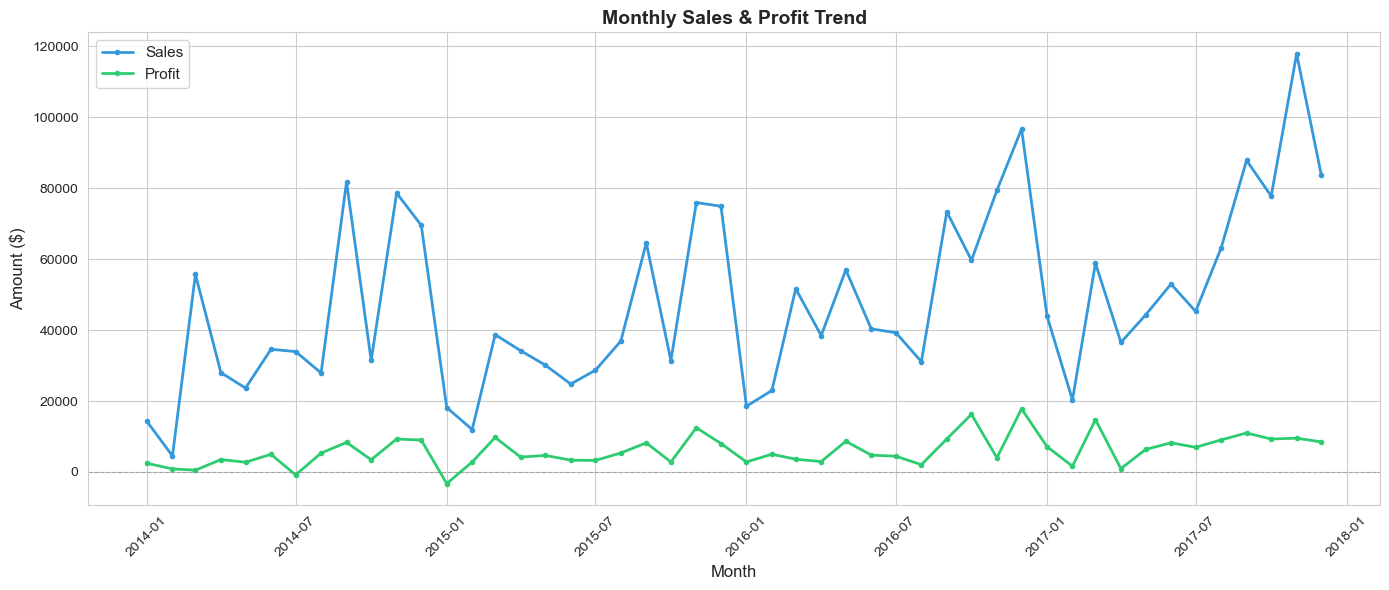

In [25]:
# --- Cell 23: Monthly Sales & Profit Trend (Dual Line Chart) ---
monthly_data = df.groupby(df['Order_Date'].dt.to_period('M')).agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).reset_index()
monthly_data['Order_Date'] = monthly_data['Order_Date'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(monthly_data['Order_Date'], monthly_data['Sales'], color='#3498db',
        linewidth=2, label='Sales', marker='o', markersize=3)
ax.plot(monthly_data['Order_Date'], monthly_data['Profit'], color='#2ecc71',
        linewidth=2, label='Profit', marker='o', markersize=3)
ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Amount ($)', fontsize=12)
ax.set_title('Monthly Sales & Profit Trend', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

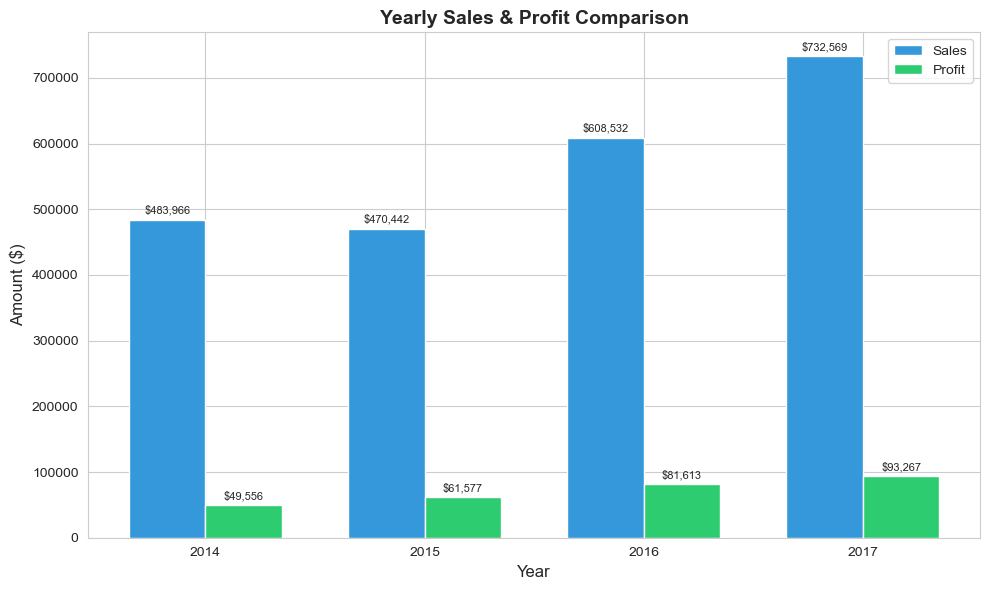

In [26]:
# --- Cell 24: Yearly Sales & Profit Comparison (Grouped Bar) ---
yearly_data = df.groupby('Order_Year').agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(yearly_data))
width = 0.35

bars1 = ax.bar(x - width/2, yearly_data['Sales'], width, label='Sales', color='#3498db')
bars2 = ax.bar(x + width/2, yearly_data['Profit'], width, label='Profit', color='#2ecc71')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Amount ($)', fontsize=12)
ax.set_title('Yearly Sales & Profit Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(yearly_data['Order_Year'].astype(int))
ax.legend()
ax.bar_label(bars1, fmt='${:,.0f}', padding=3, fontsize=8)
ax.bar_label(bars2, fmt='${:,.0f}', padding=3, fontsize=8)
plt.tight_layout()
plt.show()


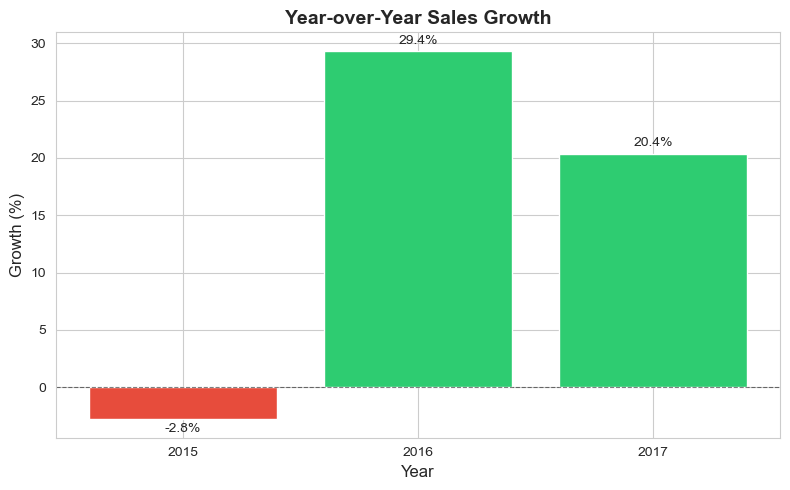

In [27]:

# --- Cell 25: Year-over-Year Sales Growth (%) ---
yearly_data['Sales_Growth'] = yearly_data['Sales'].pct_change() * 100

fig, ax = plt.subplots(figsize=(8, 5))
growth_data = yearly_data.dropna(subset=['Sales_Growth'])
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in growth_data['Sales_Growth']]
bars = ax.bar(growth_data['Order_Year'].astype(int).astype(str), growth_data['Sales_Growth'], color=colors)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Growth (%)', fontsize=12)
ax.set_title('Year-over-Year Sales Growth', fontsize=14, fontweight='bold')
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=10)
plt.tight_layout()
plt.show()

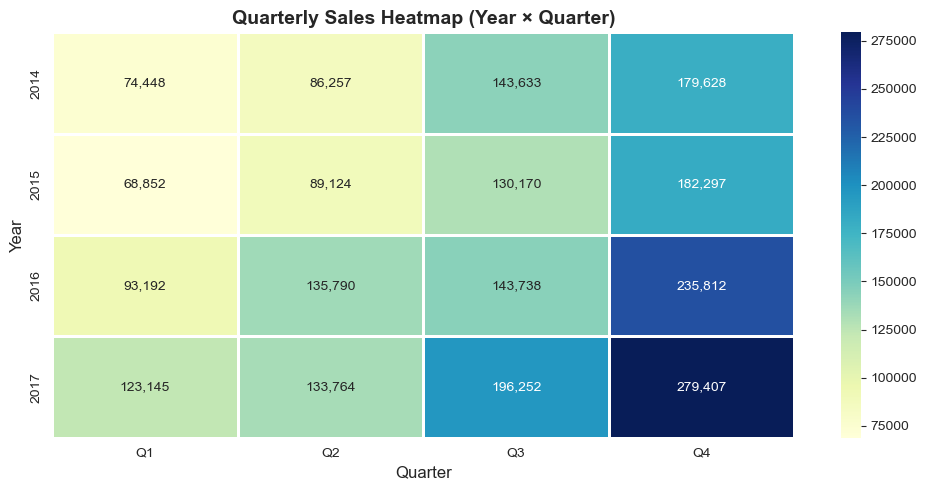

In [28]:
# --- Cell 26: Quarterly Sales Heatmap ---
quarterly_pivot = df.pivot_table(
    values='Sales', index='Order_Year', columns='Order_Quarter', aggfunc='sum'
)
quarterly_pivot.index = quarterly_pivot.index.astype(int)
quarterly_pivot.columns = [f'Q{int(c)}' for c in quarterly_pivot.columns]

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(quarterly_pivot, annot=True, fmt=',.0f', cmap='YlGnBu',
            linewidths=1, linecolor='white', ax=ax)
ax.set_title('Quarterly Sales Heatmap (Year × Quarter)', fontsize=14, fontweight='bold')
ax.set_ylabel('Year', fontsize=12)
ax.set_xlabel('Quarter', fontsize=12)
plt.tight_layout()
plt.show()

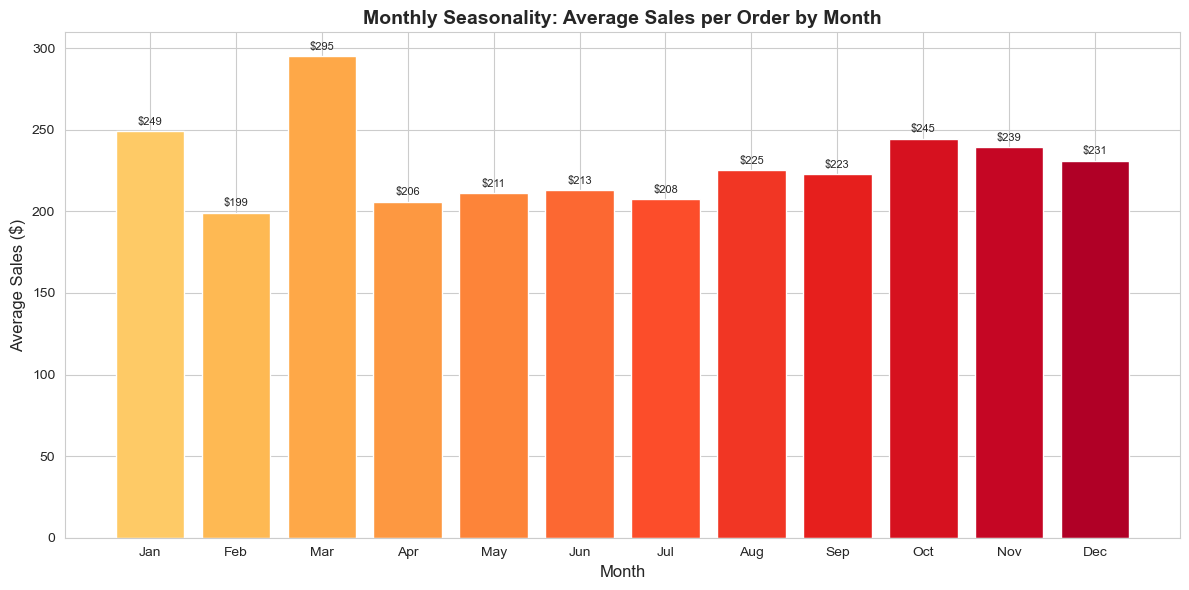

In [29]:
# --- Cell 27: Monthly Seasonality Pattern ---
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_avg = df.groupby('Month_Name')['Sales'].mean().reindex(month_order)

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, 12))
bars = ax.bar(monthly_avg.index, monthly_avg.values, color=colors, edgecolor='white')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Average Sales ($)', fontsize=12)
ax.set_title('Monthly Seasonality: Average Sales per Order by Month', fontsize=14, fontweight='bold')
ax.bar_label(bars, fmt='${:,.0f}', padding=3, fontsize=8)
plt.tight_layout()
plt.show()

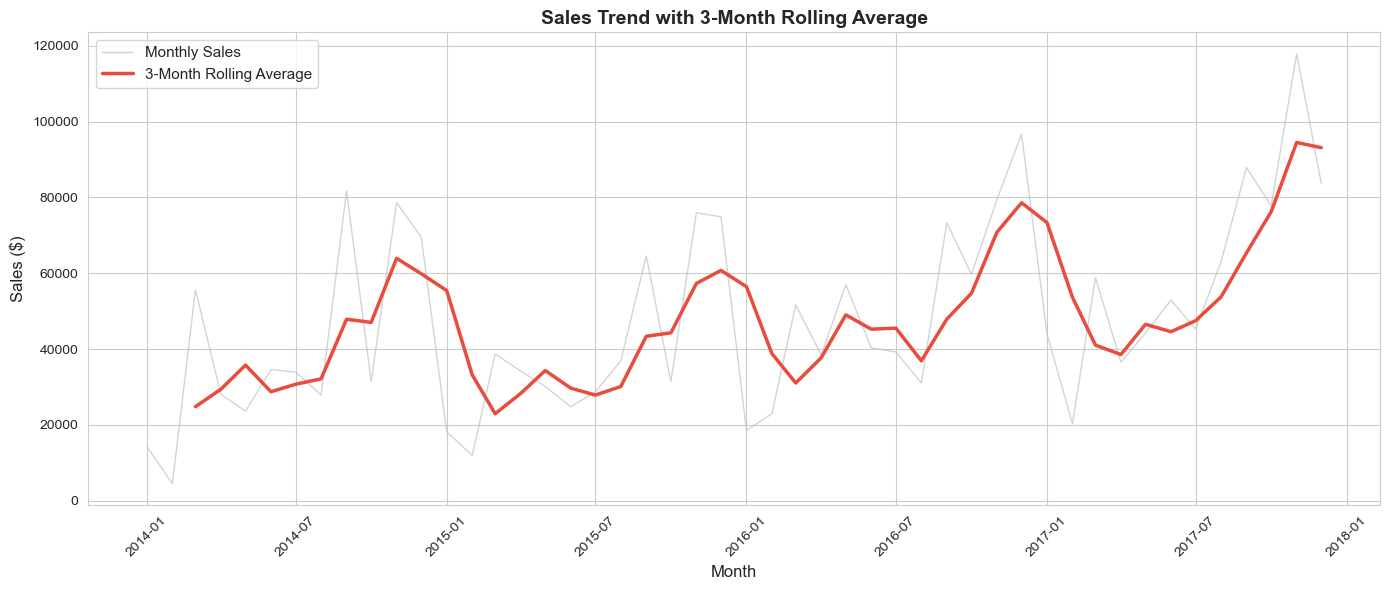

In [30]:
# --- Cell 28: 3-Month Rolling Average of Sales ---
monthly_sales = df.groupby(df['Order_Date'].dt.to_period('M'))['Sales'].sum().reset_index()
monthly_sales['Order_Date'] = monthly_sales['Order_Date'].dt.to_timestamp()
monthly_sales['Rolling_3M'] = monthly_sales['Sales'].rolling(window=3).mean()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(monthly_sales['Order_Date'], monthly_sales['Sales'], color='#bdc3c7',
        linewidth=1, alpha=0.7, label='Monthly Sales')
ax.plot(monthly_sales['Order_Date'], monthly_sales['Rolling_3M'], color='#e74c3c',
        linewidth=2.5, label='3-Month Rolling Average')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Sales ($)', fontsize=12)
ax.set_title('Sales Trend with 3-Month Rolling Average', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

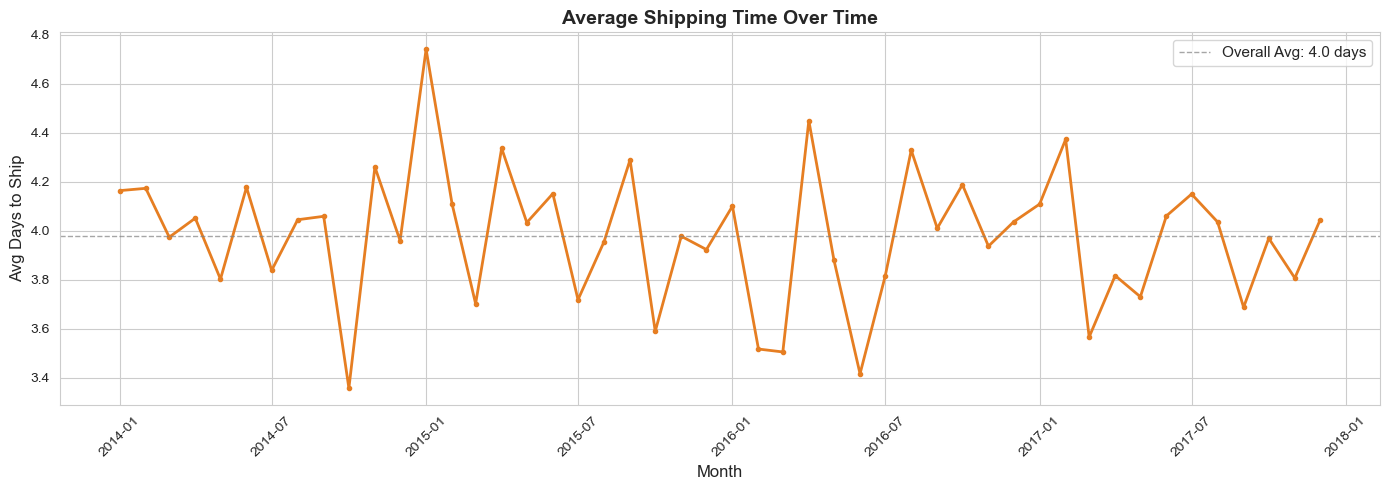

In [31]:
# --- Cell 29: Average Shipping Time Over Time ---
monthly_ship = df.groupby(df['Order_Date'].dt.to_period('M'))['Days_to_Ship'].mean().reset_index()
monthly_ship['Order_Date'] = monthly_ship['Order_Date'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_ship['Order_Date'], monthly_ship['Days_to_Ship'], color='#e67e22',
        linewidth=2, marker='o', markersize=3)
ax.axhline(y=monthly_ship['Days_to_Ship'].mean(), color='gray', linestyle='--',
           linewidth=1, alpha=0.7, label=f"Overall Avg: {monthly_ship['Days_to_Ship'].mean():.1f} days")
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Avg Days to Ship', fontsize=12)
ax.set_title('Average Shipping Time Over Time', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

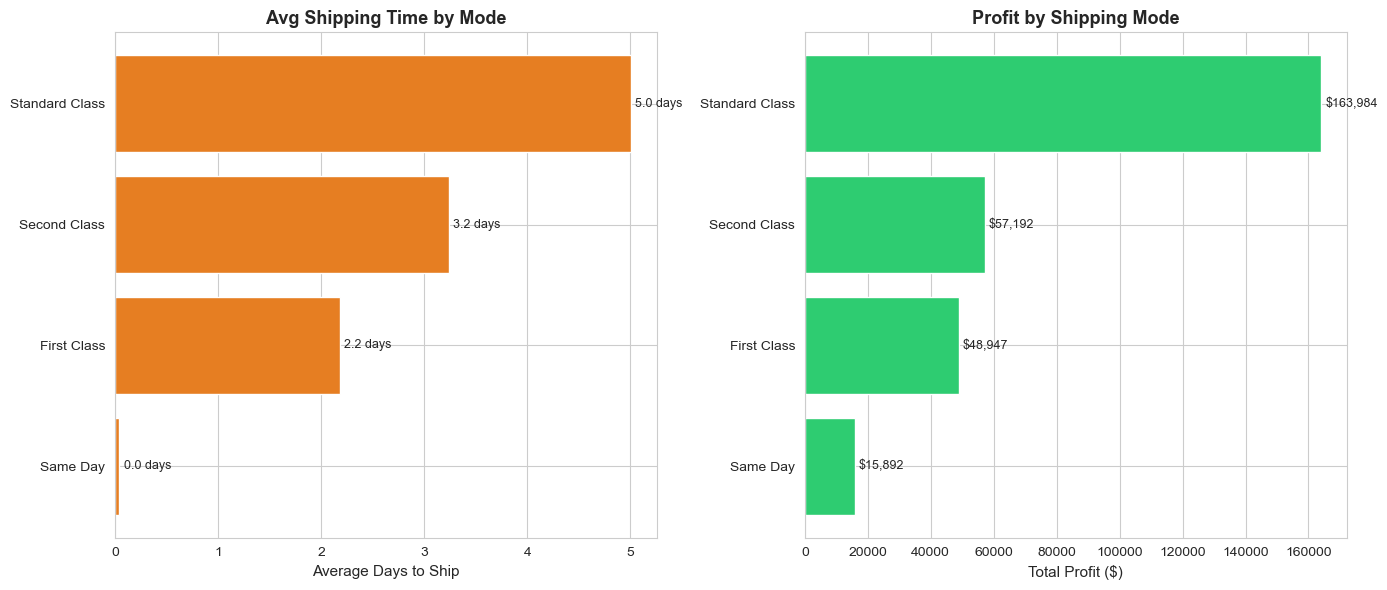

In [32]:
# --- Cell 30: Shipping Mode Performance ---
ship_mode_data = df.groupby('Ship_Mode').agg({
    'Days_to_Ship': 'mean',
    'Sales': 'sum',
    'Profit': 'sum',
    'Order_ID': 'count'
}).reset_index()
ship_mode_data.columns = ['Ship_Mode', 'Avg_Days_to_Ship', 'Total_Sales', 'Total_Profit', 'Order_Count']
ship_mode_data = ship_mode_data.sort_values('Avg_Days_to_Ship')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Avg Days to Ship
bars1 = axes[0].barh(ship_mode_data['Ship_Mode'], ship_mode_data['Avg_Days_to_Ship'], color='#e67e22')
axes[0].set_xlabel('Average Days to Ship', fontsize=11)
axes[0].set_title('Avg Shipping Time by Mode', fontsize=13, fontweight='bold')
axes[0].bar_label(bars1, fmt='%.1f days', padding=3, fontsize=9)

# Profit by Ship Mode
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in ship_mode_data['Total_Profit']]
bars2 = axes[1].barh(ship_mode_data['Ship_Mode'], ship_mode_data['Total_Profit'], color=colors)
axes[1].set_xlabel('Total Profit ($)', fontsize=11)
axes[1].set_title('Profit by Shipping Mode', fontsize=13, fontweight='bold')
axes[1].bar_label(bars2, fmt='${:,.0f}', padding=3, fontsize=9)

plt.tight_layout()
plt.show()

In [33]:
# --- Cell 31: Time Series Dashboard Summary ---
print("\n" + "=" * 60)
print("TIME SERIES DASHBOARD — KEY INSIGHTS")
print("=" * 60)

# Best & worst months
monthly_total = df.groupby('Month_Name')['Sales'].sum().reindex(month_order)
best_month = monthly_total.idxmax()
worst_month = monthly_total.idxmin()
print(f"\n1. Best Month (Total Sales): {best_month} (${monthly_total[best_month]:,.0f})")
print(f"2. Worst Month (Total Sales): {worst_month} (${monthly_total[worst_month]:,.0f})")

# Overall growth
if len(yearly_data) >= 2:
    first_year_sales = yearly_data.iloc[0]['Sales']
    last_year_sales = yearly_data.iloc[-1]['Sales']
    total_growth = ((last_year_sales - first_year_sales) / first_year_sales) * 100
    print(f"3. Overall Sales Growth ({int(yearly_data.iloc[0]['Order_Year'])}-{int(yearly_data.iloc[-1]['Order_Year'])}): {total_growth:.1f}%")

# Best quarter
best_q = quarterly_pivot.stack().idxmax()
print(f"4. Best Performing Quarter: {best_q[1]} of {best_q[0]}")

# Avg shipping time
avg_ship = df['Days_to_Ship'].mean()
print(f"5. Average Shipping Time: {avg_ship:.1f} days")

# Fastest ship mode
fastest = ship_mode_data.iloc[0]
print(f"6. Fastest Shipping Mode: {fastest['Ship_Mode']} ({fastest['Avg_Days_to_Ship']:.1f} days avg)")

print("\n" + "=" * 60)
print("ALL DASHBOARDS COMPLETE!")
print("=" * 60)



TIME SERIES DASHBOARD — KEY INSIGHTS

1. Best Month (Total Sales): Nov ($351,917)
2. Worst Month (Total Sales): Feb ($59,751)
3. Overall Sales Growth (2014-2017): 51.4%
4. Best Performing Quarter: Q4 of 2017
5. Average Shipping Time: 4.0 days
6. Fastest Shipping Mode: Same Day (0.0 days avg)

ALL DASHBOARDS COMPLETE!


In [34]:
# HELPER FUNCTION: KPI Card Drawing
# ============================================================================
def draw_kpi_card(ax, value, label, color, text_color='white'):
    """Draw a colored KPI card on the given axes."""
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    rect = mpatches.FancyBboxPatch(
        (0.02, 0.05), 0.96, 0.9,
        boxstyle="round,pad=0.05",
        facecolor=color, edgecolor='none', alpha=0.9
    )
    ax.add_patch(rect)
    ax.text(0.5, 0.62, str(value), ha='center', va='center',
            fontsize=18, fontweight='bold', color=text_color)
    ax.text(0.5, 0.28, label, ha='center', va='center',
            fontsize=10, color=text_color, alpha=0.9)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)

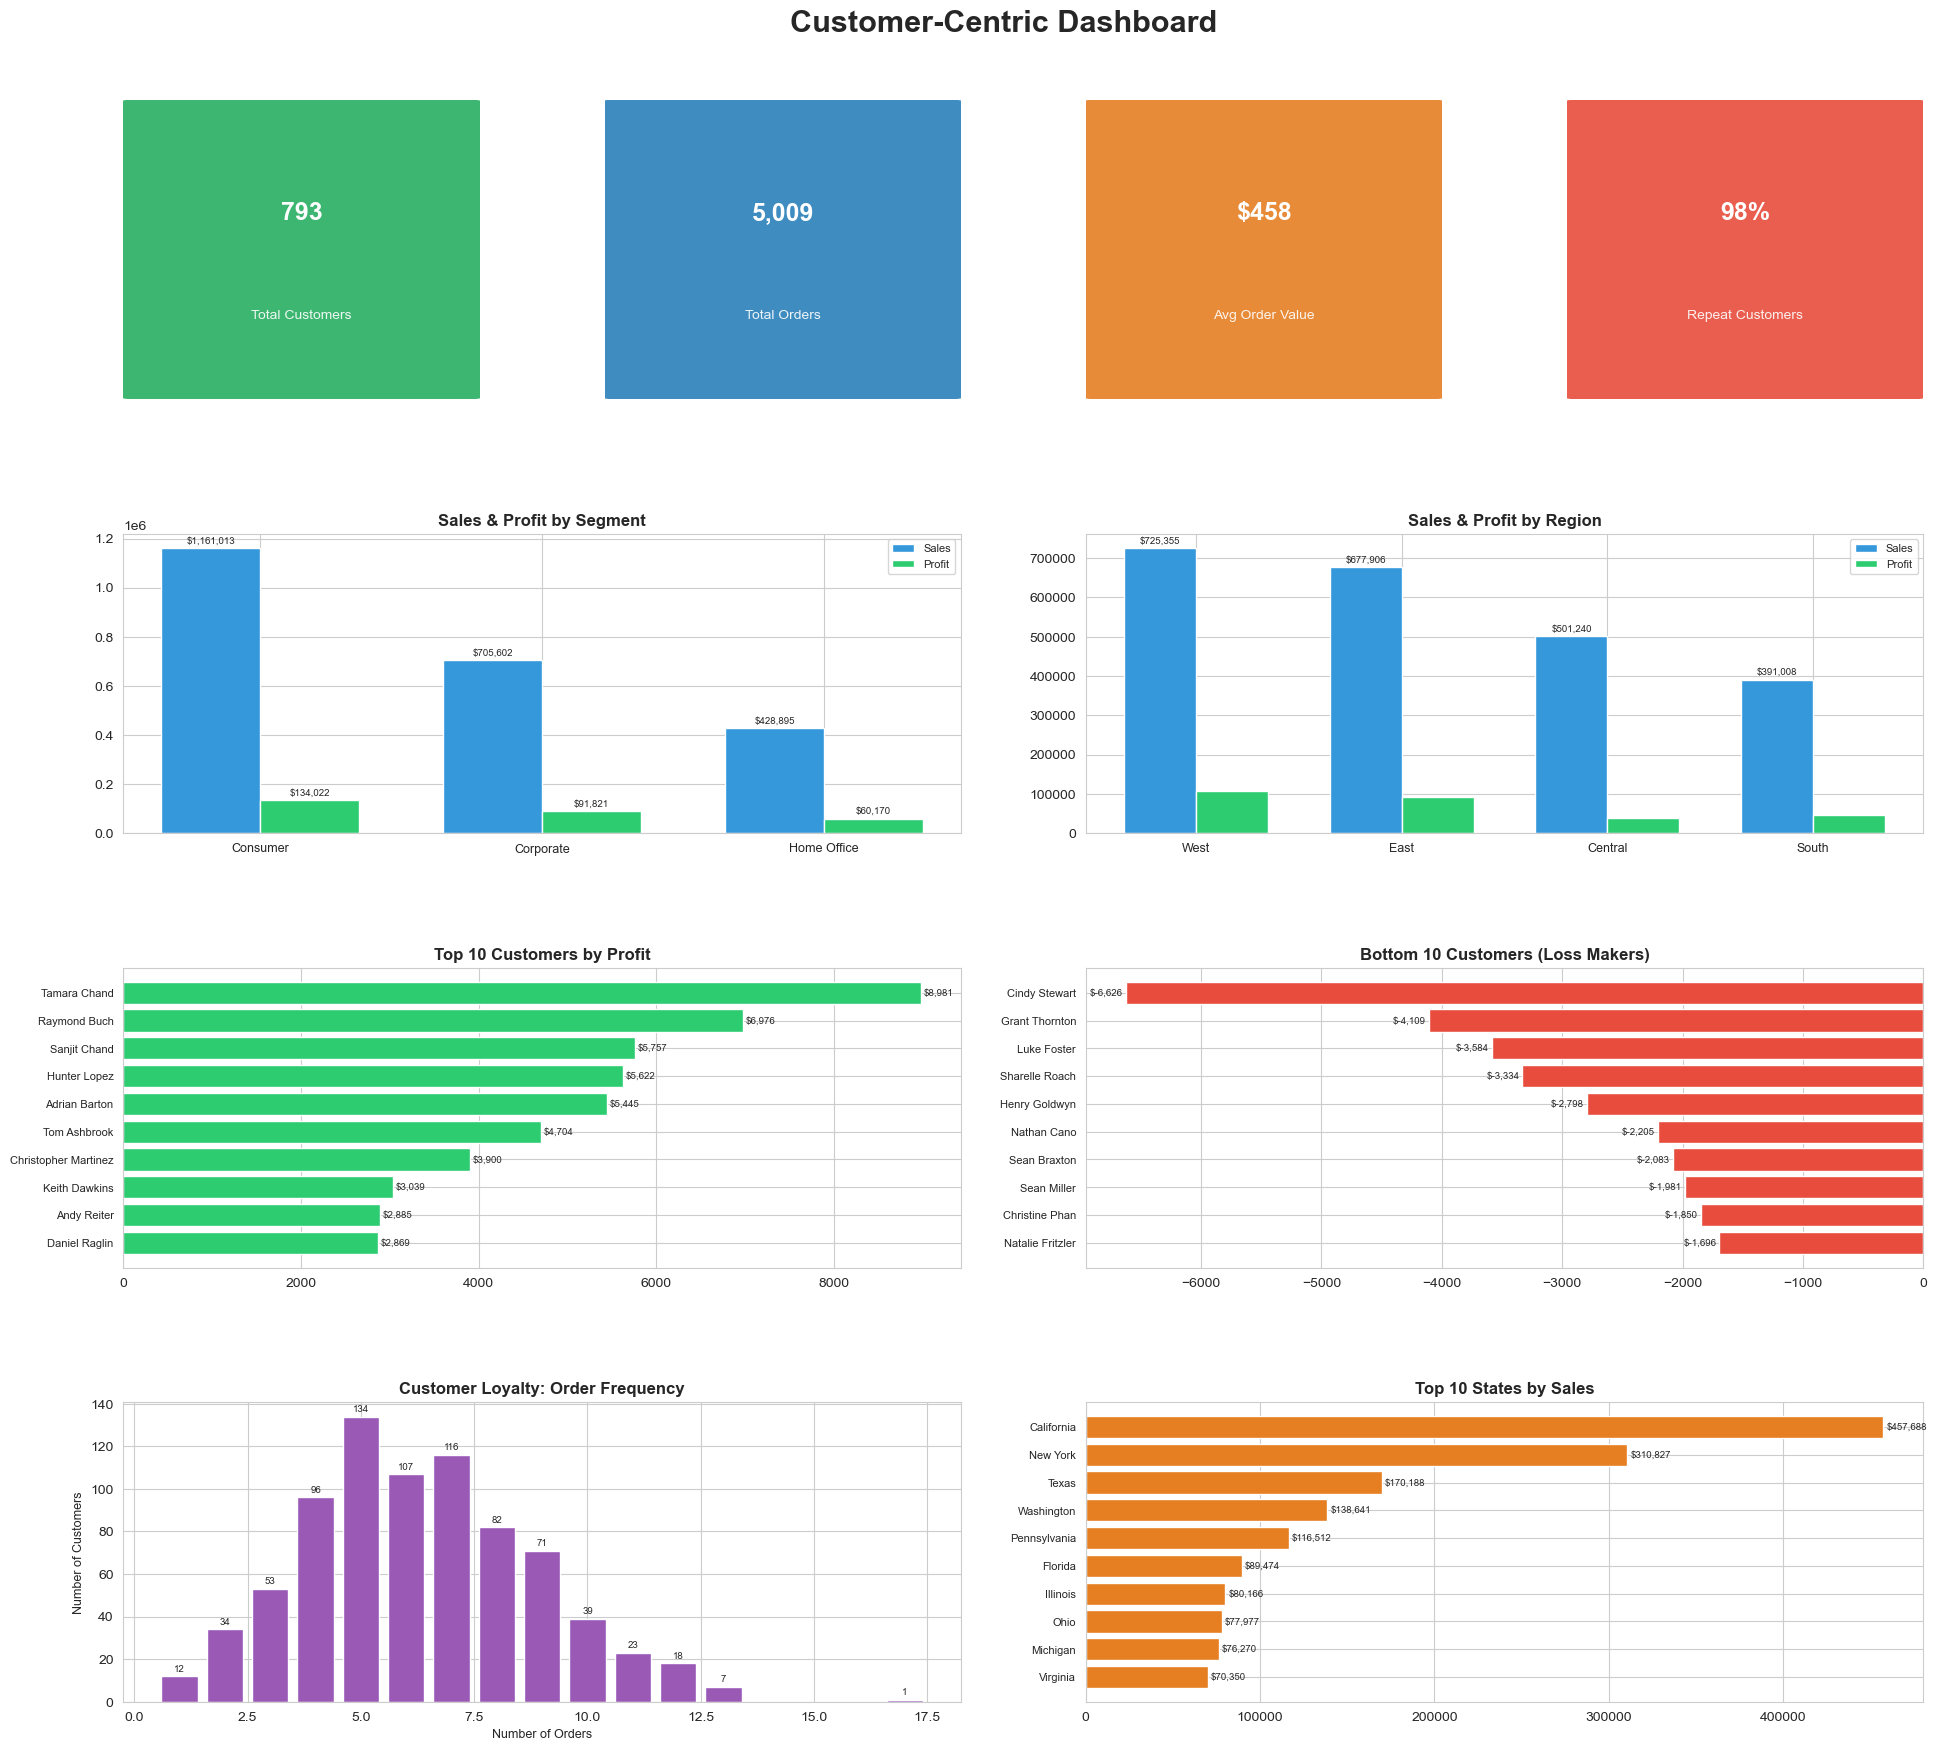

In [35]:
# ============================================================================
# DASHBOARD 1: CUSTOMER-CENTRIC (Single Consolidated Figure)
# ============================================================================
# --- Copy everything below into ONE Jupyter cell ---

# Pre-compute data
total_customers = df['Customer_Name'].nunique()
total_orders = df['Order_ID'].nunique()
total_sales_cust = df['Sales'].sum()
avg_order_value = total_sales_cust / total_orders

order_freq = df.groupby('Customer_Name')['Order_ID'].nunique()
repeat_pct = (order_freq > 1).sum() / total_customers * 100

segment_sales = df.groupby('Segment').agg({'Sales': 'sum', 'Profit': 'sum'}).reset_index()
top_segment = segment_sales.loc[segment_sales['Sales'].idxmax(), 'Segment']

region_data = df.groupby('Region').agg({'Sales': 'sum', 'Profit': 'sum'}).reset_index().sort_values('Sales', ascending=False)

top10_cust_profit = df.groupby('Customer_Name')['Profit'].sum().sort_values(ascending=False).head(10)
bottom10_cust_profit = df.groupby('Customer_Name')['Profit'].sum().sort_values(ascending=True).head(10)

top10_states = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)

freq_dist = order_freq.value_counts().sort_index()

# Build the dashboard figure
fig = plt.figure(figsize=(20, 18))
fig.suptitle('Customer-Centric Dashboard', fontsize=22, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(4, 4, hspace=0.45, wspace=0.35,
                       top=0.93, bottom=0.04, left=0.06, right=0.96)

# Row 0: KPI Cards
ax_kpi1 = fig.add_subplot(gs[0, 0])
draw_kpi_card(ax_kpi1, f'{total_customers:,}', 'Total Customers', '#27ae60')

ax_kpi2 = fig.add_subplot(gs[0, 1])
draw_kpi_card(ax_kpi2, f'{total_orders:,}', 'Total Orders', '#2980b9')

ax_kpi3 = fig.add_subplot(gs[0, 2])
draw_kpi_card(ax_kpi3, f'${avg_order_value:,.0f}', 'Avg Order Value', '#e67e22')

ax_kpi4 = fig.add_subplot(gs[0, 3])
draw_kpi_card(ax_kpi4, f'{repeat_pct:.0f}%', 'Repeat Customers', '#e74c3c')

# Row 1, Col 0-1: Sales & Profit by Segment
ax1 = fig.add_subplot(gs[1, 0:2])
x = np.arange(len(segment_sales))
w = 0.35
bars1 = ax1.bar(x - w/2, segment_sales['Sales'], w, label='Sales', color='#3498db')
bars2 = ax1.bar(x + w/2, segment_sales['Profit'], w, label='Profit', color='#2ecc71')
ax1.set_xticks(x)
ax1.set_xticklabels(segment_sales['Segment'], fontsize=9)
ax1.set_title('Sales & Profit by Segment', fontsize=12, fontweight='bold')
ax1.legend(fontsize=8)
ax1.bar_label(bars1, fmt='${:,.0f}', fontsize=7, padding=2)
ax1.bar_label(bars2, fmt='${:,.0f}', fontsize=7, padding=2)

# Row 1, Col 2-3: Sales & Profit by Region
ax2 = fig.add_subplot(gs[1, 2:4])
x = np.arange(len(region_data))
bars1 = ax2.bar(x - w/2, region_data['Sales'], w, label='Sales', color='#3498db')
bars2 = ax2.bar(x + w/2, region_data['Profit'], w, label='Profit',
                color=['#2ecc71' if v > 0 else '#e74c3c' for v in region_data['Profit']])
ax2.set_xticks(x)
ax2.set_xticklabels(region_data['Region'], fontsize=9)
ax2.set_title('Sales & Profit by Region', fontsize=12, fontweight='bold')
ax2.legend(fontsize=8)
ax2.bar_label(bars1, fmt='${:,.0f}', fontsize=7, padding=2)

# Row 2, Col 0-1: Top 10 Customers by Profit
ax3 = fig.add_subplot(gs[2, 0:2])
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in top10_cust_profit.values]
bars = ax3.barh(top10_cust_profit.index[::-1], top10_cust_profit.values[::-1], color=colors[::-1])
ax3.set_title('Top 10 Customers by Profit', fontsize=12, fontweight='bold')
ax3.bar_label(bars, fmt='${:,.0f}', fontsize=7, padding=2)
ax3.tick_params(axis='y', labelsize=8)

# Row 2, Col 2-3: Bottom 10 Customers by Profit
ax4 = fig.add_subplot(gs[2, 2:4])
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in bottom10_cust_profit.values]
bars = ax4.barh(bottom10_cust_profit.index[::-1], bottom10_cust_profit.values[::-1], color=colors[::-1])
ax4.set_title('Bottom 10 Customers (Loss Makers)', fontsize=12, fontweight='bold')
ax4.bar_label(bars, fmt='${:,.0f}', fontsize=7, padding=2)
ax4.tick_params(axis='y', labelsize=8)

# Row 3, Col 0-1: Customer Order Frequency
ax5 = fig.add_subplot(gs[3, 0:2])
bars = ax5.bar(freq_dist.index, freq_dist.values, color='#9b59b6', edgecolor='white')
ax5.set_xlabel('Number of Orders', fontsize=9)
ax5.set_ylabel('Number of Customers', fontsize=9)
ax5.set_title('Customer Loyalty: Order Frequency', fontsize=12, fontweight='bold')
ax5.bar_label(bars, fontsize=7, padding=2)

# Row 3, Col 2-3: Top 10 States by Sales
ax6 = fig.add_subplot(gs[3, 2:4])
bars = ax6.barh(top10_states.index[::-1], top10_states.values[::-1], color='#e67e22')
ax6.set_title('Top 10 States by Sales', fontsize=12, fontweight='bold')
ax6.bar_label(bars, fmt='${:,.0f}', fontsize=7, padding=2)
ax6.tick_params(axis='y', labelsize=8)

plt.show()


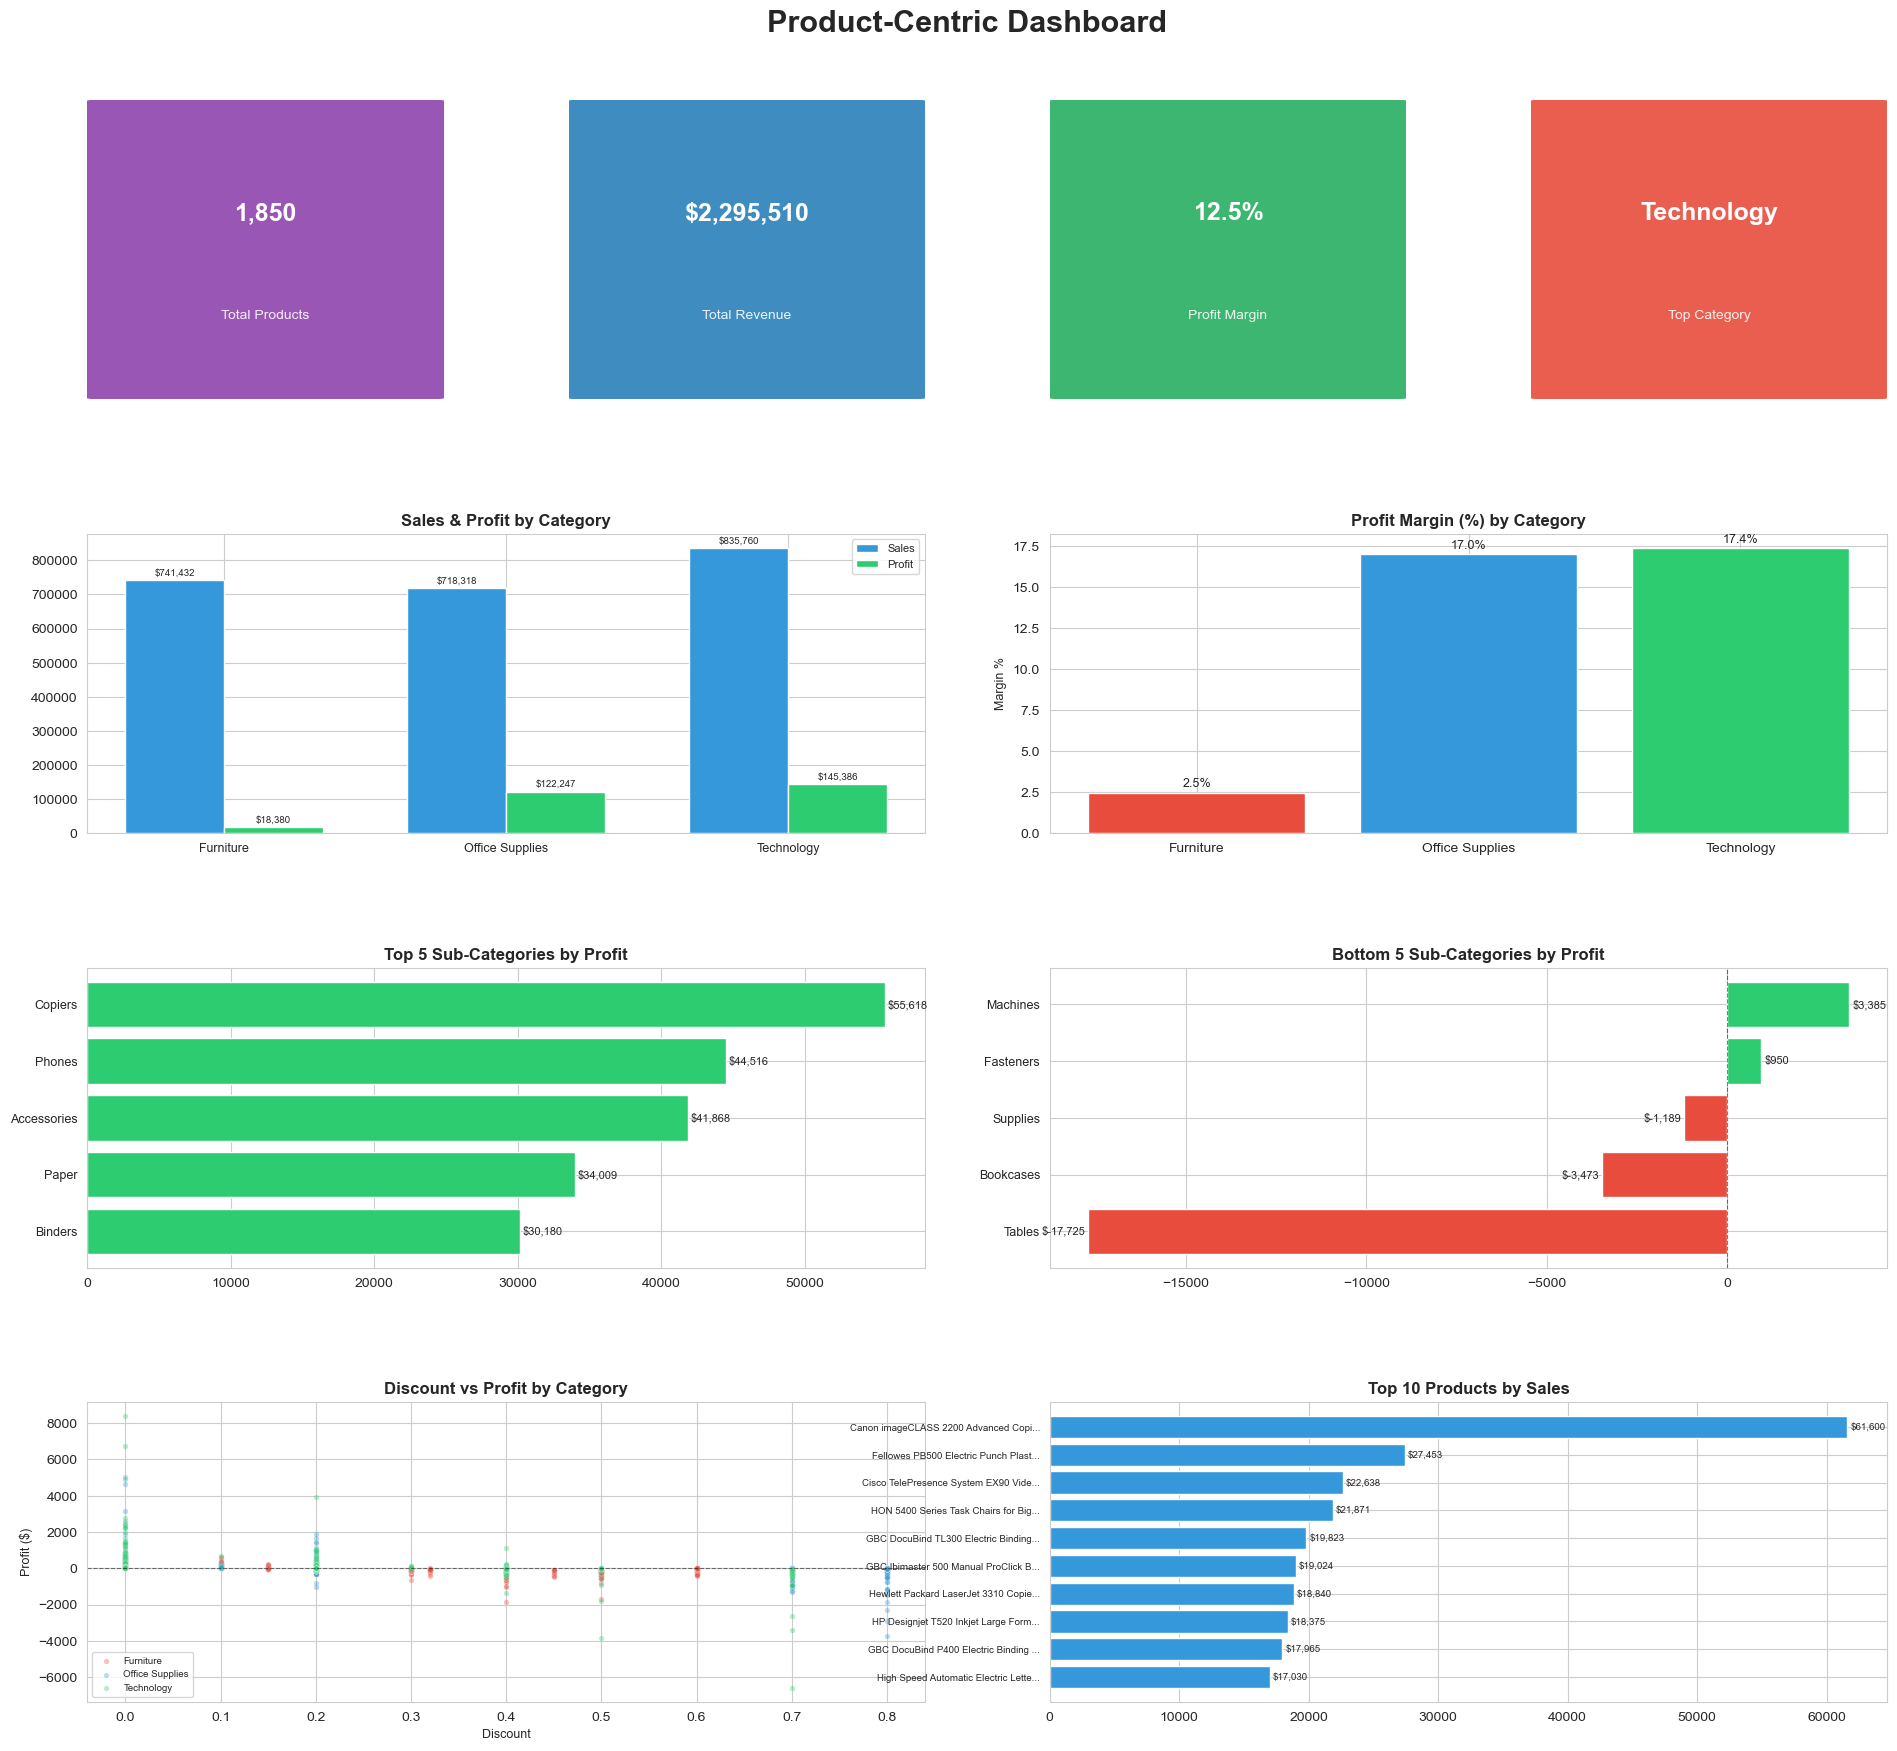

In [36]:
# ============================================================================
# DASHBOARD 2: PRODUCT-CENTRIC (Single Consolidated Figure)
# ============================================================================
# --- Copy everything below into ONE Jupyter cell ---

# Pre-compute data
total_products = df['Product_Name'].nunique()
total_revenue = df['Sales'].sum()
total_profit = df['Profit'].sum()
overall_margin = (total_profit / total_revenue) * 100

category_data = df.groupby('Category').agg({'Sales': 'sum', 'Profit': 'sum'}).reset_index()
category_data['Margin'] = (category_data['Profit'] / category_data['Sales']) * 100
best_cat = category_data.loc[category_data['Profit'].idxmax(), 'Category']

subcat_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False)
top5_subcat = subcat_profit.head(5)
bottom5_subcat = subcat_profit.tail(5).sort_values()

avg_discount_subcat = df.groupby('Sub-Category')['Discount'].mean().sort_values(ascending=True)

top10_products = df.groupby('Product_Name')['Sales'].sum().sort_values(ascending=False).head(10)

loss_products_count = (df.groupby('Product_Name')['Profit'].sum() < 0).sum()

# Build the dashboard figure
fig = plt.figure(figsize=(20, 18))
fig.suptitle('Product-Centric Dashboard', fontsize=22, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(4, 4, hspace=0.45, wspace=0.35,
                       top=0.93, bottom=0.04, left=0.06, right=0.96)

# Row 0: KPI Cards
ax_kpi1 = fig.add_subplot(gs[0, 0])
draw_kpi_card(ax_kpi1, f'{total_products:,}', 'Total Products', '#8e44ad')

ax_kpi2 = fig.add_subplot(gs[0, 1])
draw_kpi_card(ax_kpi2, f'${total_revenue:,.0f}', 'Total Revenue', '#2980b9')

ax_kpi3 = fig.add_subplot(gs[0, 2])
draw_kpi_card(ax_kpi3, f'{overall_margin:.1f}%', 'Profit Margin', '#27ae60')

ax_kpi4 = fig.add_subplot(gs[0, 3])
draw_kpi_card(ax_kpi4, f'{best_cat}', 'Top Category', '#e74c3c')

# Row 1, Col 0-1: Sales & Profit by Category
ax1 = fig.add_subplot(gs[1, 0:2])
cat_colors = ['#e74c3c', '#3498db', '#2ecc71']
x = np.arange(len(category_data))
w = 0.35
bars1 = ax1.bar(x - w/2, category_data['Sales'], w, label='Sales', color='#3498db')
bars2 = ax1.bar(x + w/2, category_data['Profit'], w, label='Profit', color='#2ecc71')
ax1.set_xticks(x)
ax1.set_xticklabels(category_data['Category'], fontsize=9)
ax1.set_title('Sales & Profit by Category', fontsize=12, fontweight='bold')
ax1.legend(fontsize=8)
ax1.bar_label(bars1, fmt='${:,.0f}', fontsize=7, padding=2)
ax1.bar_label(bars2, fmt='${:,.0f}', fontsize=7, padding=2)

# Row 1, Col 2-3: Profit Margin by Category
ax2 = fig.add_subplot(gs[1, 2:4])
bars = ax2.bar(category_data['Category'], category_data['Margin'], color=cat_colors)
ax2.set_title('Profit Margin (%) by Category', fontsize=12, fontweight='bold')
ax2.set_ylabel('Margin %', fontsize=9)
ax2.bar_label(bars, fmt='%.1f%%', fontsize=9, padding=2)

# Row 2, Col 0-1: Top 5 Sub-Categories by Profit
ax3 = fig.add_subplot(gs[2, 0:2])
bars = ax3.barh(top5_subcat.index[::-1], top5_subcat.values[::-1], color='#2ecc71')
ax3.set_title('Top 5 Sub-Categories by Profit', fontsize=12, fontweight='bold')
ax3.bar_label(bars, fmt='${:,.0f}', fontsize=8, padding=2)
ax3.tick_params(axis='y', labelsize=9)

# Row 2, Col 2-3: Bottom 5 Sub-Categories by Profit
ax4 = fig.add_subplot(gs[2, 2:4])
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in bottom5_subcat.values]
bars = ax4.barh(bottom5_subcat.index, bottom5_subcat.values, color=colors)
ax4.set_title('Bottom 5 Sub-Categories by Profit', fontsize=12, fontweight='bold')
ax4.axvline(x=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax4.bar_label(bars, fmt='${:,.0f}', fontsize=8, padding=2)
ax4.tick_params(axis='y', labelsize=9)

# Row 3, Col 0-1: Discount vs Profit Scatter
ax5 = fig.add_subplot(gs[3, 0:2])
cat_color_map = {'Furniture': '#e74c3c', 'Office Supplies': '#3498db', 'Technology': '#2ecc71'}
for cat, color in cat_color_map.items():
    mask = df['Category'] == cat
    ax5.scatter(df.loc[mask, 'Discount'], df.loc[mask, 'Profit'],
                c=color, label=cat, alpha=0.35, s=15, edgecolors='white', linewidth=0.3)
ax5.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax5.set_xlabel('Discount', fontsize=9)
ax5.set_ylabel('Profit ($)', fontsize=9)
ax5.set_title('Discount vs Profit by Category', fontsize=12, fontweight='bold')
ax5.legend(fontsize=7, loc='lower left')

# Row 3, Col 2-3: Top 10 Products by Sales
ax6 = fig.add_subplot(gs[3, 2:4])
short_names = [n[:35] + '...' if len(n) > 35 else n for n in top10_products.index[::-1]]
bars = ax6.barh(short_names, top10_products.values[::-1], color='#3498db')
ax6.set_title('Top 10 Products by Sales', fontsize=12, fontweight='bold')
ax6.bar_label(bars, fmt='${:,.0f}', fontsize=7, padding=2)
ax6.tick_params(axis='y', labelsize=7)

plt.show()

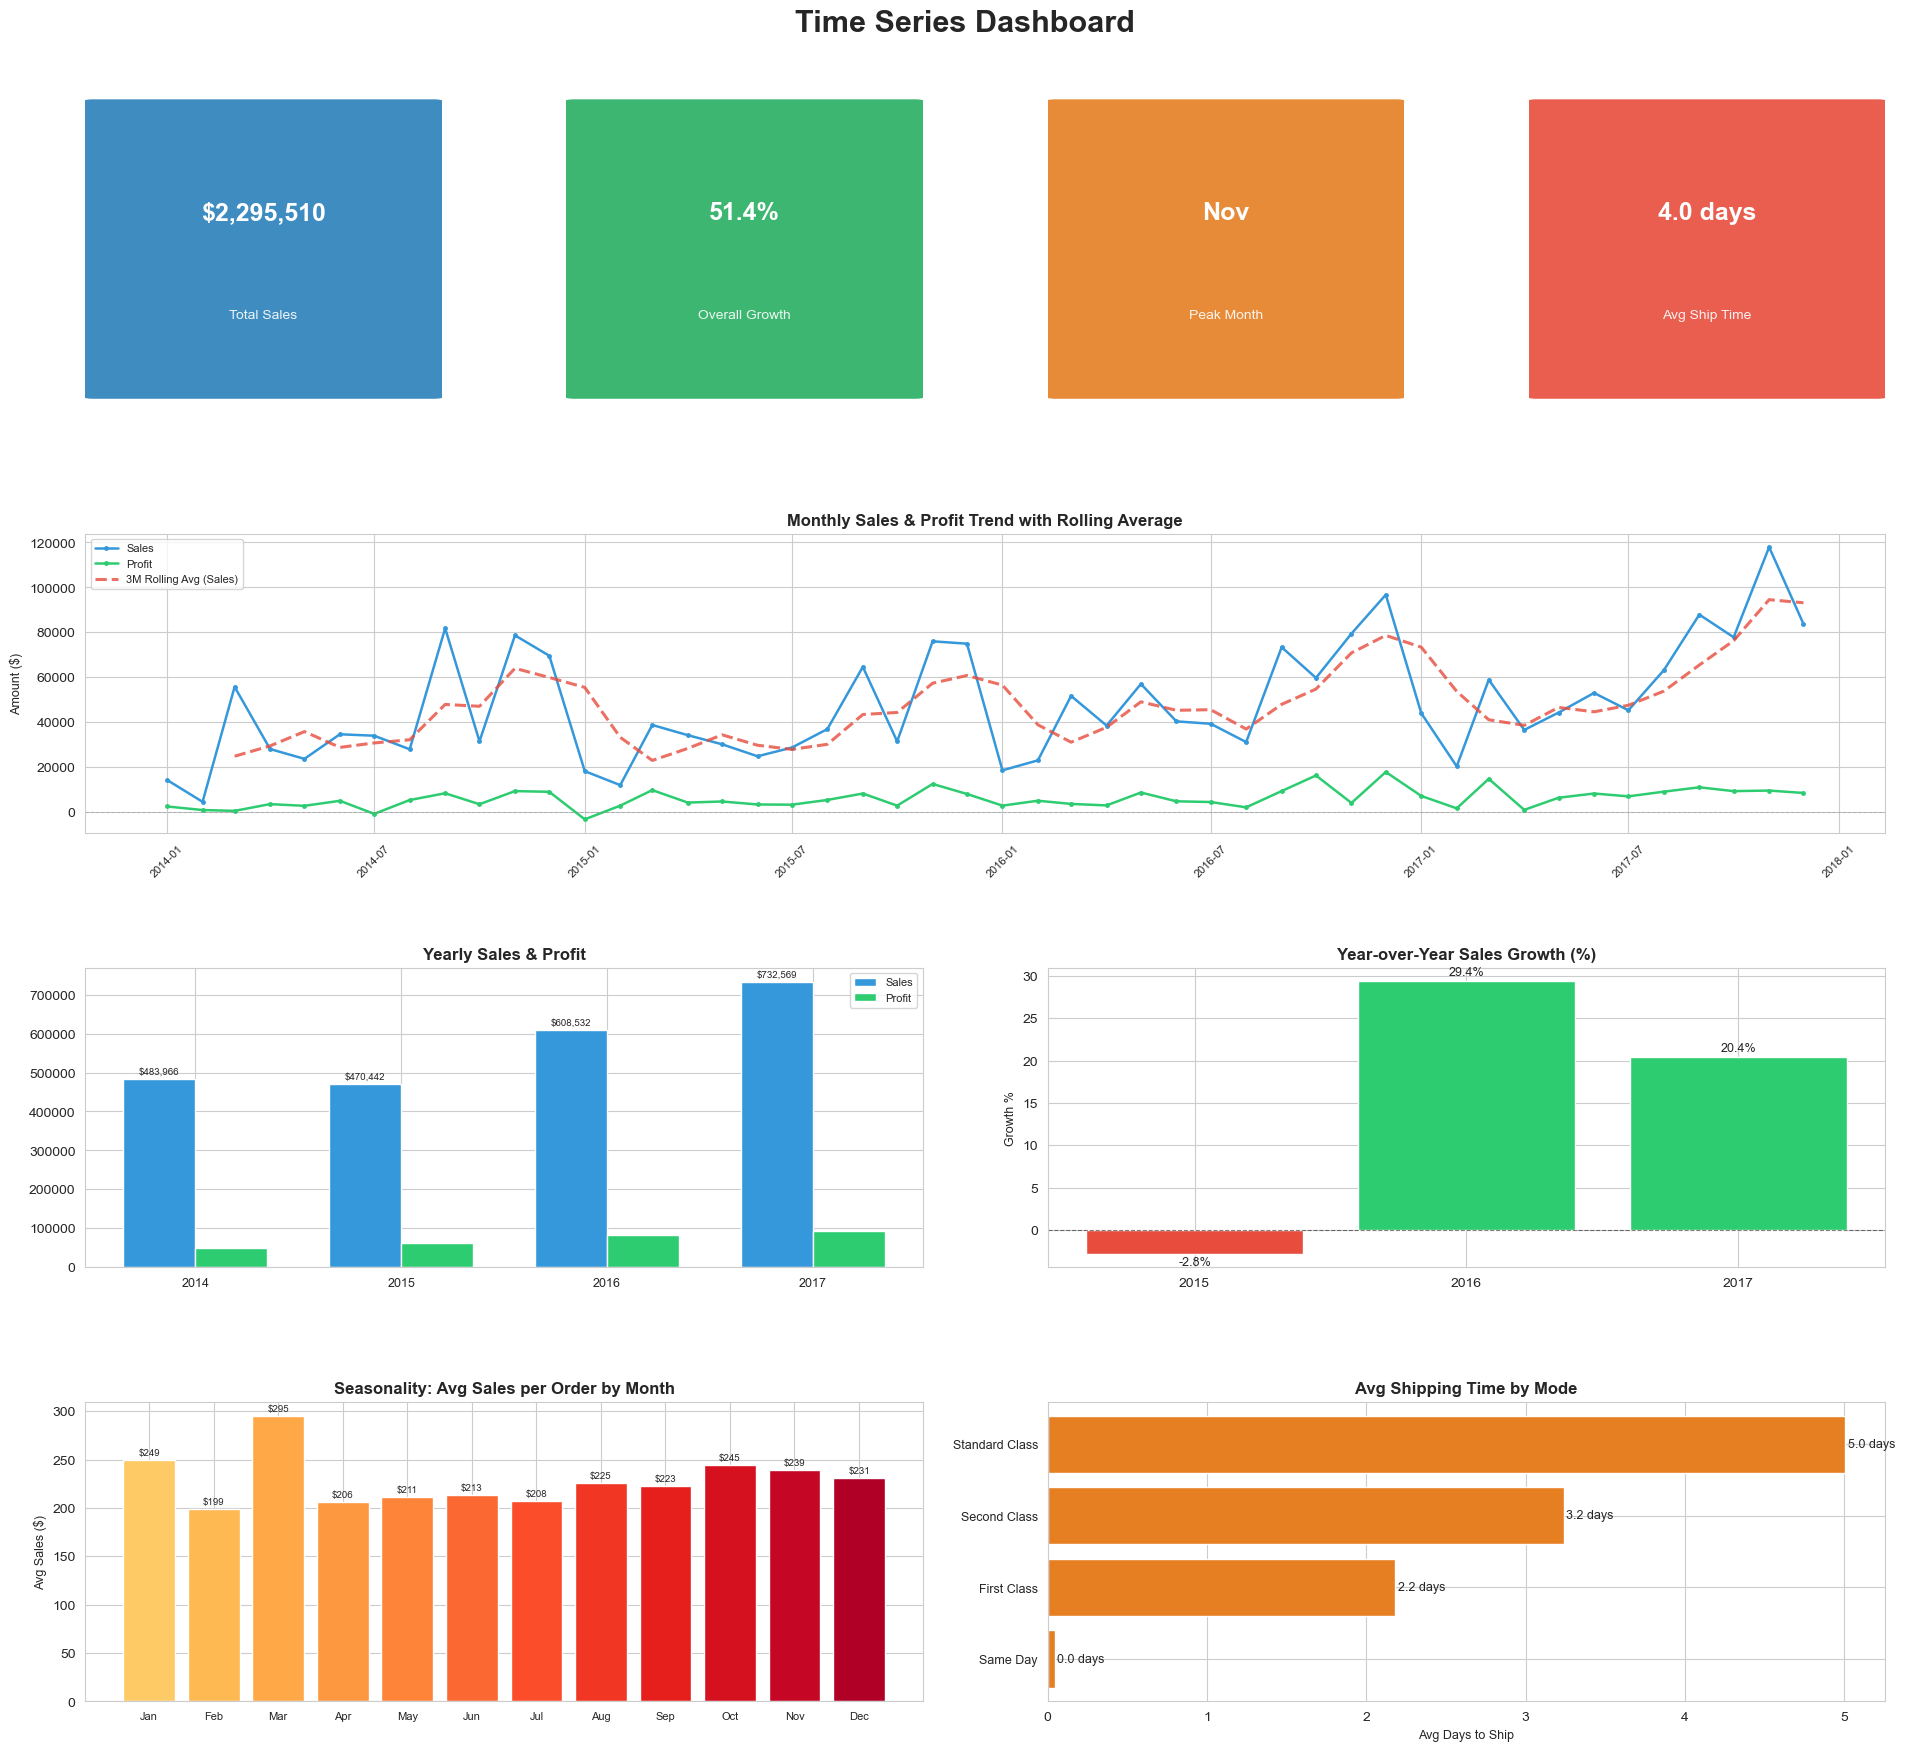

In [37]:
# ============================================================================
# DASHBOARD 3: TIME SERIES-CENTRIC (Single Consolidated Figure)
# ============================================================================
# --- Copy everything below into ONE Jupyter cell ---

# Pre-compute data
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

yearly_data = df.groupby('Order_Year').agg({'Sales': 'sum', 'Profit': 'sum'}).reset_index()
yearly_data['Growth'] = yearly_data['Sales'].pct_change() * 100

monthly_ts = df.groupby(df['Order_Date'].dt.to_period('M')).agg({
    'Sales': 'sum', 'Profit': 'sum'
}).reset_index()
monthly_ts['Order_Date'] = monthly_ts['Order_Date'].dt.to_timestamp()
monthly_ts['Rolling_3M'] = monthly_ts['Sales'].rolling(window=3).mean()

monthly_season = df.groupby('Month_Name')['Sales'].mean().reindex(month_order)
best_month = df.groupby('Month_Name')['Sales'].sum().reindex(month_order).idxmax()

quarterly_pivot = df.pivot_table(values='Sales', index='Order_Year',
                                 columns='Order_Quarter', aggfunc='sum')
quarterly_pivot.index = quarterly_pivot.index.astype(int)
quarterly_pivot.columns = [f'Q{int(c)}' for c in quarterly_pivot.columns]

avg_ship_time = df['Days_to_Ship'].mean()

ship_mode_data = df.groupby('Ship_Mode').agg({
    'Days_to_Ship': 'mean', 'Sales': 'sum', 'Profit': 'sum'
}).reset_index().sort_values('Days_to_Ship')

if len(yearly_data) >= 2:
    overall_growth = ((yearly_data.iloc[-1]['Sales'] - yearly_data.iloc[0]['Sales']) / yearly_data.iloc[0]['Sales']) * 100
else:
    overall_growth = 0

# Build the dashboard figure
fig = plt.figure(figsize=(20, 18))
fig.suptitle('Time Series Dashboard', fontsize=22, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(4, 4, hspace=0.45, wspace=0.35,
                       top=0.93, bottom=0.04, left=0.06, right=0.96)

# Row 0: KPI Cards
ax_kpi1 = fig.add_subplot(gs[0, 0])
draw_kpi_card(ax_kpi1, f'${df["Sales"].sum():,.0f}', 'Total Sales', '#2980b9')

ax_kpi2 = fig.add_subplot(gs[0, 1])
draw_kpi_card(ax_kpi2, f'{overall_growth:.1f}%', 'Overall Growth', '#27ae60')

ax_kpi3 = fig.add_subplot(gs[0, 2])
draw_kpi_card(ax_kpi3, f'{best_month}', 'Peak Month', '#e67e22')

ax_kpi4 = fig.add_subplot(gs[0, 3])
draw_kpi_card(ax_kpi4, f'{avg_ship_time:.1f} days', 'Avg Ship Time', '#e74c3c')

# Row 1, Col 0-3: Monthly Sales & Profit Trend (full width)
ax1 = fig.add_subplot(gs[1, :])
ax1.plot(monthly_ts['Order_Date'], monthly_ts['Sales'], color='#3498db',
         linewidth=1.8, label='Sales', marker='o', markersize=2.5)
ax1.plot(monthly_ts['Order_Date'], monthly_ts['Profit'], color='#2ecc71',
         linewidth=1.8, label='Profit', marker='o', markersize=2.5)
ax1.plot(monthly_ts['Order_Date'], monthly_ts['Rolling_3M'], color='#e74c3c',
         linewidth=2.2, linestyle='--', label='3M Rolling Avg (Sales)', alpha=0.8)
ax1.axhline(y=0, color='gray', linestyle='--', linewidth=0.7, alpha=0.4)
ax1.set_title('Monthly Sales & Profit Trend with Rolling Average', fontsize=12, fontweight='bold')
ax1.legend(fontsize=8)
ax1.tick_params(axis='x', rotation=45, labelsize=8)
ax1.set_ylabel('Amount ($)', fontsize=9)

# Row 2, Col 0-1: Yearly Sales Comparison
ax2 = fig.add_subplot(gs[2, 0:2])
x = np.arange(len(yearly_data))
w = 0.35
bars1 = ax2.bar(x - w/2, yearly_data['Sales'], w, label='Sales', color='#3498db')
bars2 = ax2.bar(x + w/2, yearly_data['Profit'], w, label='Profit', color='#2ecc71')
ax2.set_xticks(x)
ax2.set_xticklabels(yearly_data['Order_Year'].astype(int), fontsize=9)
ax2.set_title('Yearly Sales & Profit', fontsize=12, fontweight='bold')
ax2.legend(fontsize=8)
ax2.bar_label(bars1, fmt='${:,.0f}', fontsize=7, padding=2)

# Row 2, Col 2-3: YoY Growth
ax3 = fig.add_subplot(gs[2, 2:4])
growth_data = yearly_data.dropna(subset=['Growth'])
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in growth_data['Growth']]
bars = ax3.bar(growth_data['Order_Year'].astype(int).astype(str), growth_data['Growth'], color=colors)
ax3.set_title('Year-over-Year Sales Growth (%)', fontsize=12, fontweight='bold')
ax3.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax3.bar_label(bars, fmt='%.1f%%', fontsize=9, padding=2)
ax3.set_ylabel('Growth %', fontsize=9)

# Row 3, Col 0-1: Monthly Seasonality Pattern
ax4 = fig.add_subplot(gs[3, 0:2])
colors_season = plt.cm.YlOrRd(np.linspace(0.3, 0.9, 12))
bars = ax4.bar(monthly_season.index, monthly_season.values, color=colors_season, edgecolor='white')
ax4.set_title('Seasonality: Avg Sales per Order by Month', fontsize=12, fontweight='bold')
ax4.set_ylabel('Avg Sales ($)', fontsize=9)
ax4.tick_params(axis='x', labelsize=8)
ax4.bar_label(bars, fmt='${:,.0f}', fontsize=7, padding=2)

# Row 3, Col 2-3: Shipping Mode Performance
ax5 = fig.add_subplot(gs[3, 2:4])
bars = ax5.barh(ship_mode_data['Ship_Mode'], ship_mode_data['Days_to_Ship'], color='#e67e22')
ax5.set_title('Avg Shipping Time by Mode', fontsize=12, fontweight='bold')
ax5.set_xlabel('Avg Days to Ship', fontsize=9)
ax5.bar_label(bars, fmt='%.1f days', fontsize=9, padding=2)
ax5.tick_params(axis='y', labelsize=9)

plt.show()
